In [25]:
import numpy as np
import pandas as pd
import os, json, re
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from math import ceil
from pathlib import Path
from typing import List, Optional, Dict, Tuple

In [3]:
from visualize import (
    collect_results_among_seeds,
    plot_metric_heatmap,
    plot_dumbbell_vs_vanilla,
    plot_grouped_bars_per_dataset,
    plot_table_with_bars,
    win_counts,
    plot_win_counts,
    plot_fairness_utility_tradeoff,
    plot_delta_heatmaps,
)

# 06 Feb 2026 - k=2 with lambda_dp = lambda_eo = 0.0

## Import results

In [60]:
EXP_DIR = "../logs/compare_edgeadder_vs_advtrain_expB"

In [ ]:
df_attacked = collect_results_among_seeds(EXP_DIR, verbose=True)
df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_attacked.shape

In [ ]:
df_attacked.columns

Index(['method', 'dataset', 'encoder', 'model', 'timestamp', 'n_seeds',
       'AUC_mean', 'AUC_std', 'F1_mean', 'F1_std', 'ACC_mean', 'ACC_std',
       'DP_mean', 'DP_std', 'EO_mean', 'EO_std', 'name'],
      dtype='object')

In [ ]:
df_attacked["method"].value_counts()

method
vanilla             27
vanilla_advtrain    27
edge_adder          26
Name: count, dtype: int64

In [ ]:
C_10seeds = df_attacked["n_seeds"] == 10
df_attacked[C_10seeds].shape

(75, 17)

In [ ]:
pts_attacked = {}

In [ ]:
metric = "DP_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            7.26   8.76  10.28   4.42   4.62
        edge_adder         5.92   7.46   7.54  10.34   6.06
        vanilla_advtrain   7.53   8.30  10.88   2.12   4.26
german  vanilla            2.28   6.97  13.69  19.94  11.05
        edge_adder         6.06   2.71   3.31   5.44   2.29
        vanilla_advtrain   0.92   6.39  13.42  28.67  11.31
nba     vanilla           23.54  51.12  11.24   9.43  47.54
        edge_adder        20.05  28.24   6.62  10.03  37.32
        vanilla_advtrain  22.77  41.17  23.72  12.85  37.65
pokec_n vanilla           29.61  22.13  35.31  28.78  30.12
        edge_adder        26.70   7.52  28.43   3.55   6.59
        vanilla_advtrain   9.87   8.82  20.11  11.17  24.49
pokec_z vanilla           40.60  31.37  39.02  28.48  37.10
        edge_adder        16.95   9.57  17.01  17.77   5.23
        vanilla_advtrain   9.56  11.34  20.85  11.31  12.91

In [ ]:
metric = "EO_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            4.91   4.30   6.43   1.76   2.70
        edge_adder         3.42   3.14   5.83   8.52   3.11
        vanilla_advtrain   4.97   4.21   7.13   1.30   2.82
german  vanilla            2.80   6.05  10.11  20.34  10.75
        edge_adder         7.44   2.17   4.88   2.63   1.97
        vanilla_advtrain   0.83   5.17  10.41  22.07   9.67
nba     vanilla           23.00  33.67   7.33   8.67  41.00
        edge_adder        22.00  13.00   8.67  10.00  26.33
        vanilla_advtrain  16.67  22.67  18.67   9.00  34.00
pokec_n vanilla           26.73  20.97  34.50  24.67  28.67
        edge_adder        23.70   7.36  24.71   1.97   5.83
        vanilla_advtrain  10.70   8.53  20.09  10.28  25.15
pokec_z vanilla           33.37  26.25  38.08  26.04  29.42
        edge_adder        14.66   8.23  17.42  14.92   4.64
        vanilla_advtrain   9.73  10.25  20.84  10.98  11.14

In [ ]:
metric = "F1_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           84.30  77.51  70.28  80.69  80.23
        edge_adder        79.50  79.80  72.77  80.31  80.25
        vanilla_advtrain  84.13  78.69  70.69  81.94  80.71
german  vanilla           43.70  49.42  74.54  61.07  68.71
        edge_adder        67.20  34.74  53.19  77.59  63.26
        vanilla_advtrain  59.00  57.34  67.89  73.87  67.37
nba     vanilla           64.65  69.65  55.24  56.48  65.33
        edge_adder        67.45  72.63  47.24  55.27  65.75
        vanilla_advtrain  68.74  71.80  53.57  58.08  66.29
pokec_n vanilla           63.67  65.65  57.90  65.57  65.61
        edge_adder        61.25  67.51  61.97  67.06  67.66
        vanilla_advtrain  63.13  65.40  57.81  65.96  65.35
pokec_z vanilla           66.66  68.14  58.99  61.47  68.09
        edge_adder        68.27  70.32  64.42  71.80  68.85
        vanilla_advtrain  66.68  69.01  62.89  66.24  69.74

In [ ]:
metric = "AUC_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           93.00  88.35  83.30  91.30  90.10
        edge_adder        90.12  89.45  83.90  90.23  89.70
        vanilla_advtrain  93.42  88.67  83.75  91.14  90.13
german  vanilla           50.38  55.60  70.76  67.37  60.06
        edge_adder        61.37  53.78  62.74  72.14  54.32
        vanilla_advtrain  49.76  54.87  69.37  70.27  59.96
nba     vanilla           66.88  71.59  60.67  65.28  73.46
        edge_adder        72.63  75.67  61.06  62.29  73.67
        vanilla_advtrain  71.54  75.59  60.29  64.49  74.89
pokec_n vanilla           69.78  74.11  62.96  68.22  72.52
        edge_adder        61.57  76.51  68.62  74.83  75.43
        vanilla_advtrain  74.86  75.71  68.92  73.62  73.76
pokec_z vanilla           70.57  75.58  66.32  69.90  74.09
        edge_adder        66.46  78.04  70.51  77.87  76.75
        vanilla_advtrain  75.18  77.59  71.12  76.04  75.55

## Visualize results

### Heatmaps

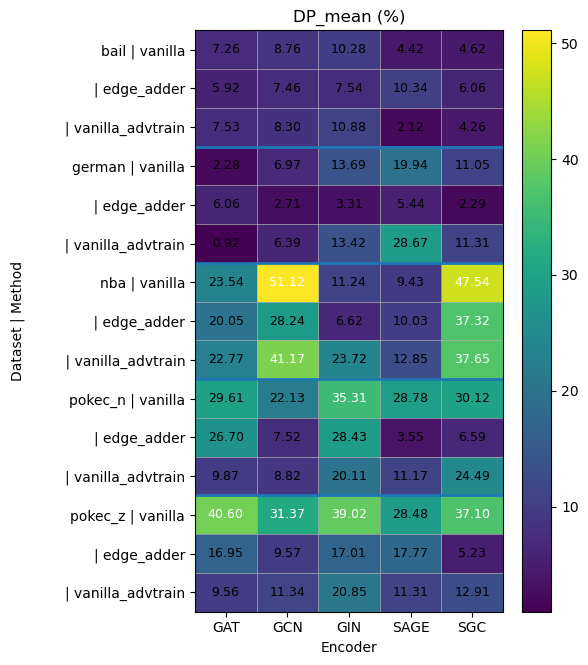

In [ ]:
metric = "DP_mean"
pt = (pts_attacked[metric] * 100).round(2)
plot_metric_heatmap(pt, title=f"{metric} (%)", annotate=True)
plt.show()

/tmp/ipykernel_3791361/127163005.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


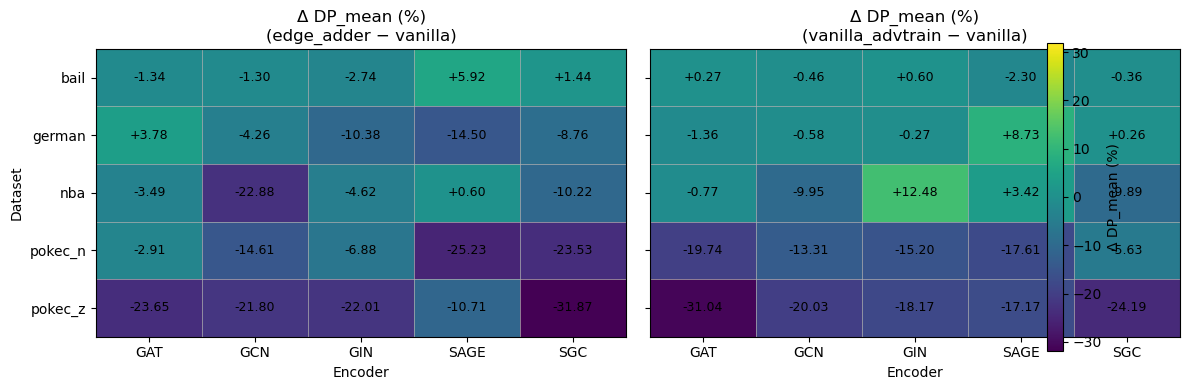

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)
plot_delta_heatmaps(pt_percent, methods=("edge_adder", "vanilla_advtrain"), metric_name="DP_mean (%)")
plt.show()

### Dumbbell Charts

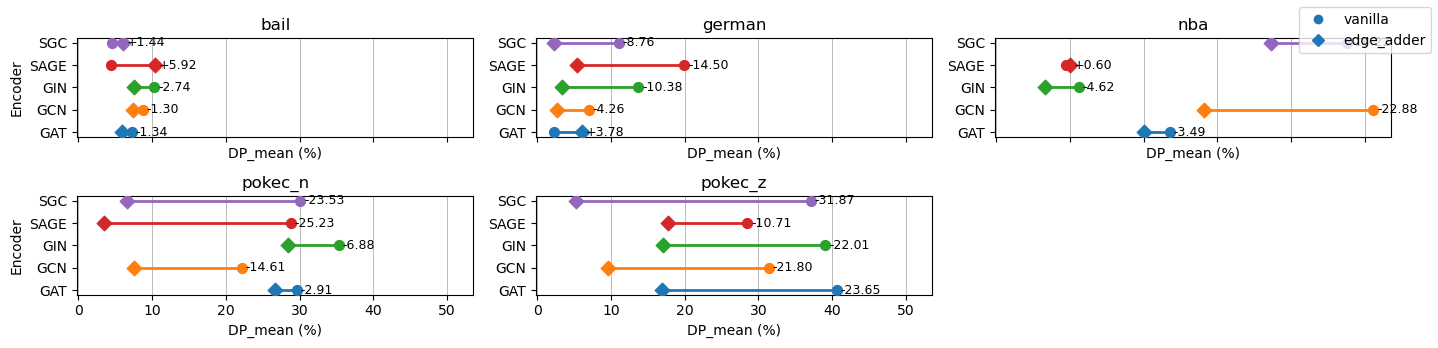

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_dumbbell_vs_vanilla(
    pt_percent,
    target_method="edge_adder",        # or "vanilla_advtrain"
    baseline_method="vanilla",
    metric_label="DP_mean (%)",
    annotate_delta=True,
    sort_encoders_by_delta=False,      # set True if you want strongest effects grouped
)
plt.show()

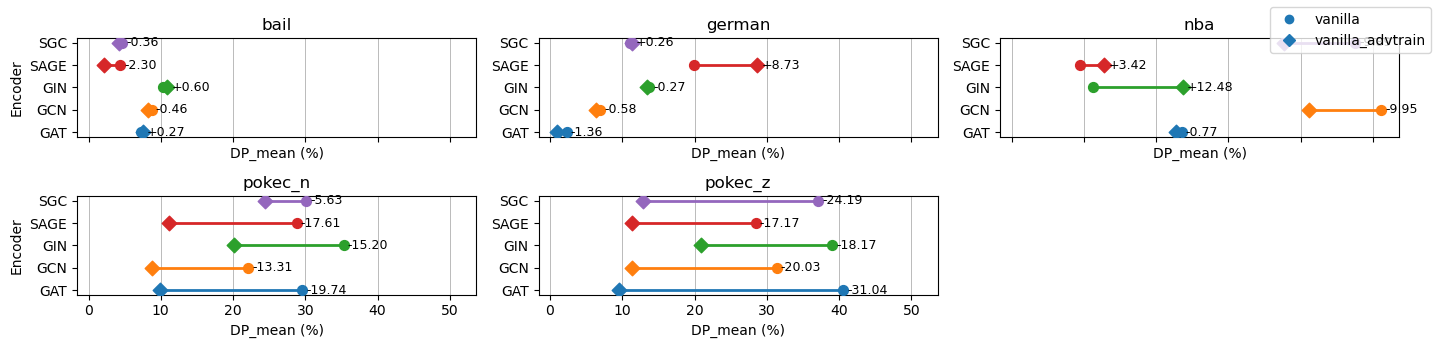

In [40]:
plot_dumbbell_vs_vanilla(
    pt_percent,
    target_method="vanilla_advtrain",        # or "vanilla_advtrain"
    baseline_method="vanilla",
    metric_label="DP_mean (%)",
    annotate_delta=True,
    sort_encoders_by_delta=False,      # set True if you want strongest effects grouped
)
plt.show()

### Grouped Bar Charts

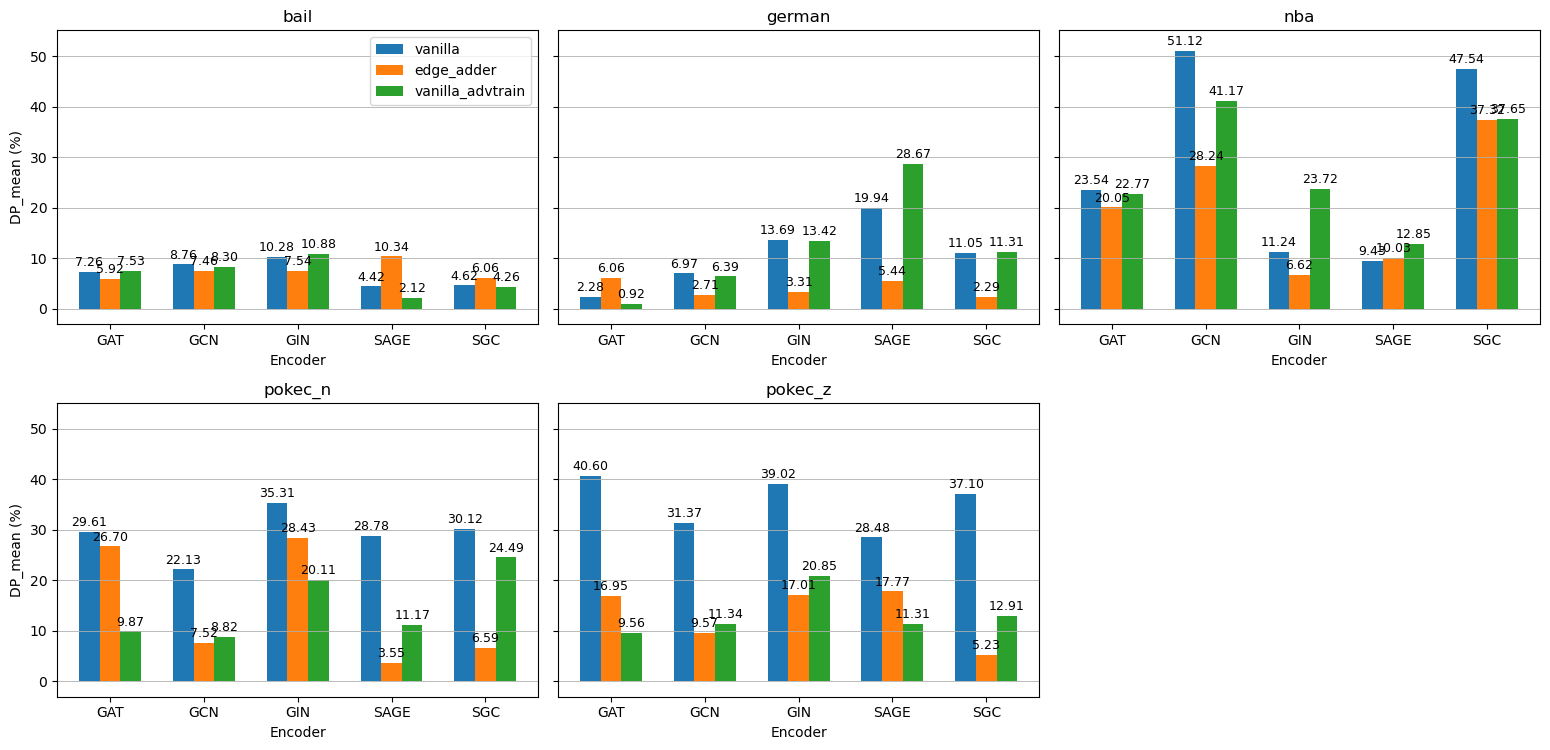

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="DP_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

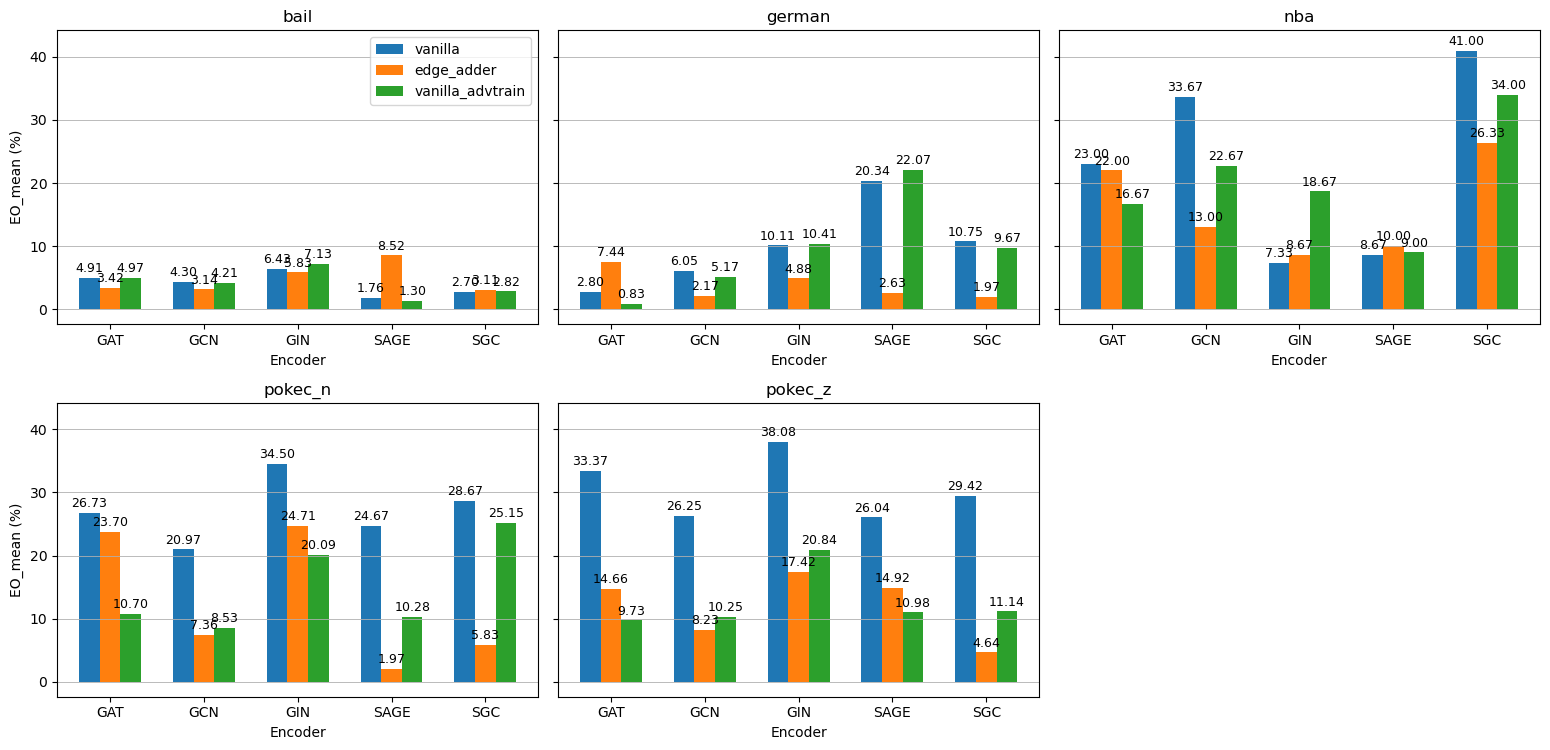

In [ ]:
metric = "EO_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="EO_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

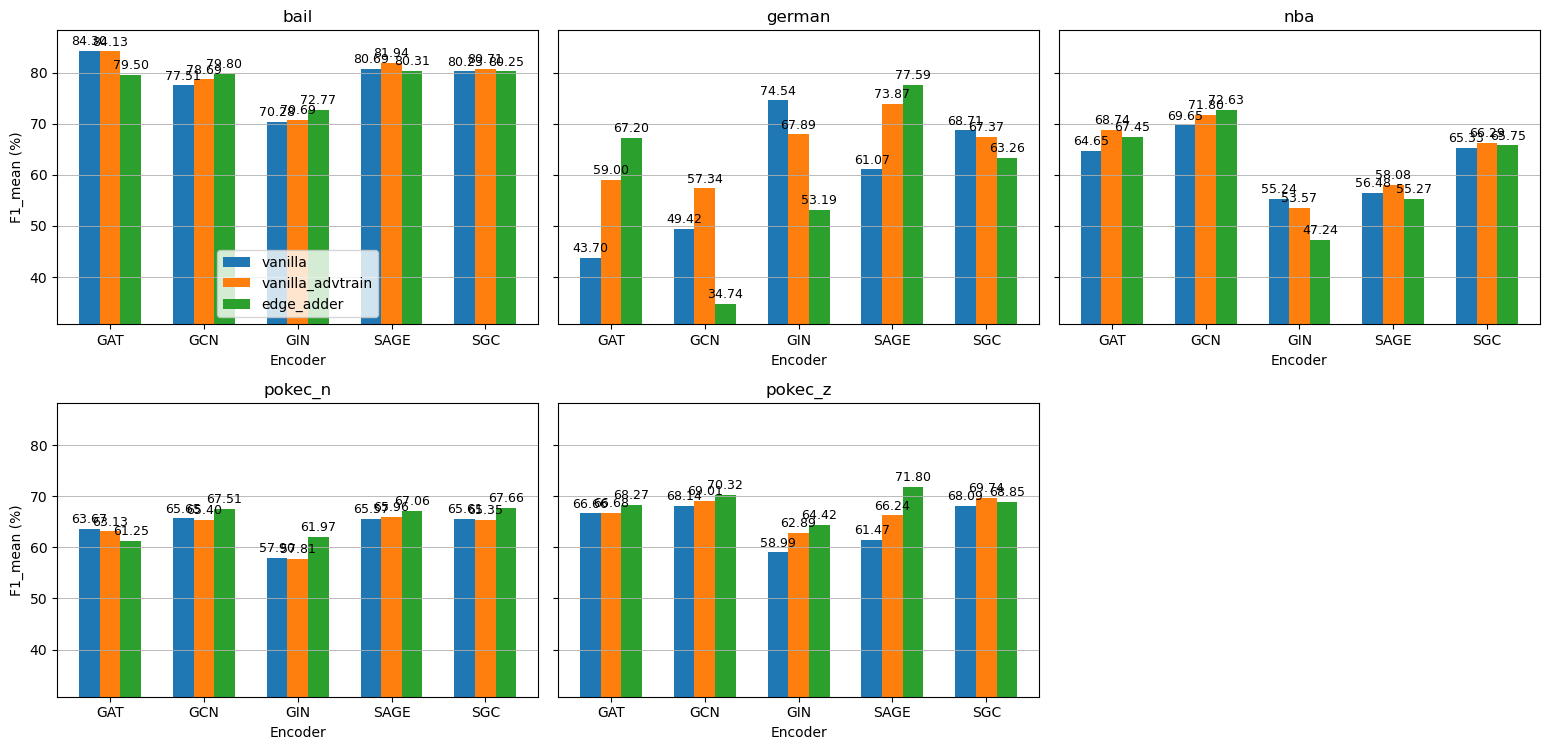

In [ ]:
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "vanilla_advtrain", "edge_adder"),
    metric_label="F1_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

### Table with Bar Charts

In [ ]:
# pt_percent: index=[dataset, method], cols=[encoder], values in %
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

(
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)  # scale bars per COLUMN (encoder) across all rows
)

In [ ]:
# pt_percent: index=[dataset, method], cols=[encoder], values in %
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

(
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)  # scale bars per COLUMN (encoder) across all rows
)

In [46]:
html = (
    pt_percent.style
    .format("{:.2f}")
    .bar(axis=0)
    .to_html()
)
with open("dp_table_with_bars.html", "w", encoding="utf-8") as f:
    f.write(html)

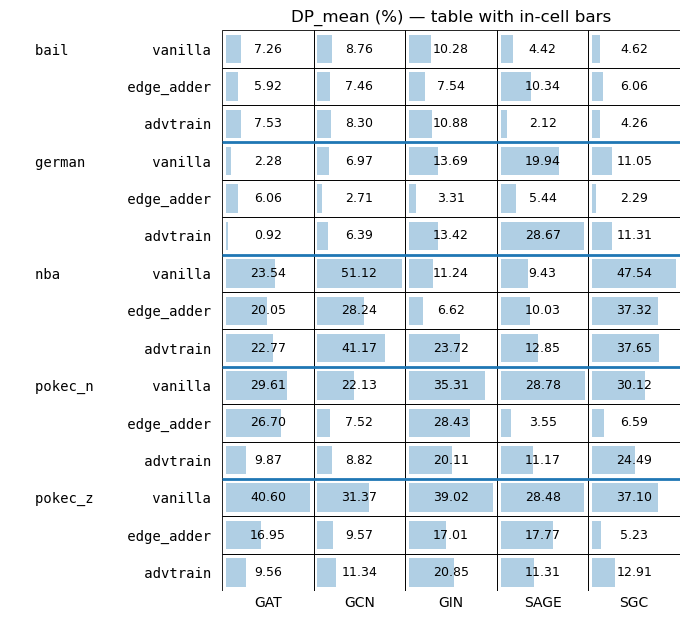

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="DP_mean (%) — table with in-cell bars", scale="col")
plt.show()

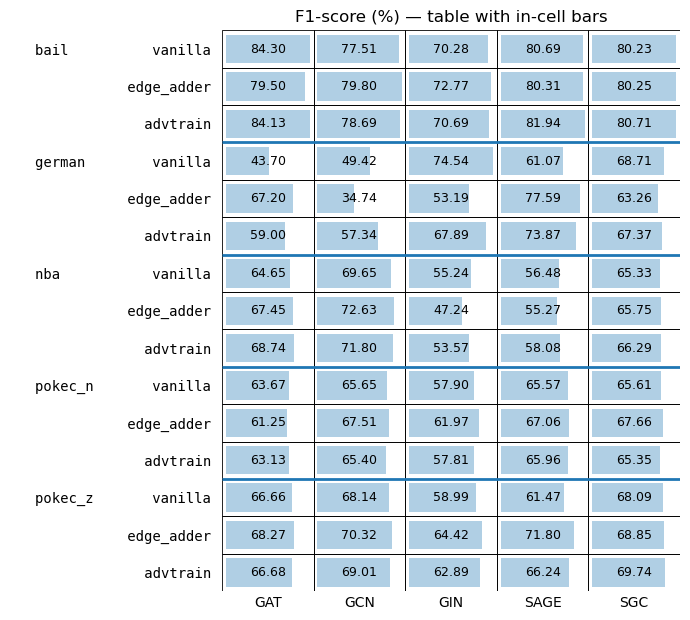

In [ ]:
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="F1-score (%) — table with in-cell bars", scale="col")
plt.show()

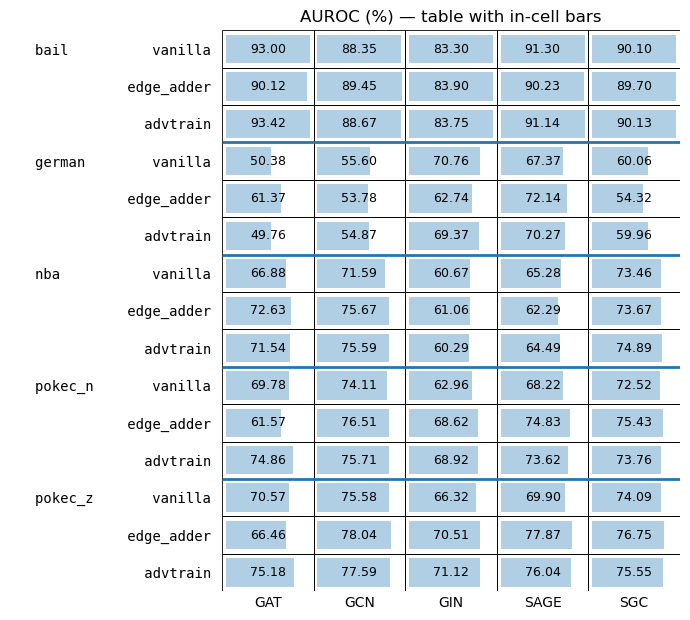

In [ ]:
metric = "AUC_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="AUROC (%) — table with in-cell bars", scale="col")
plt.show()

### Rank Bar Charts

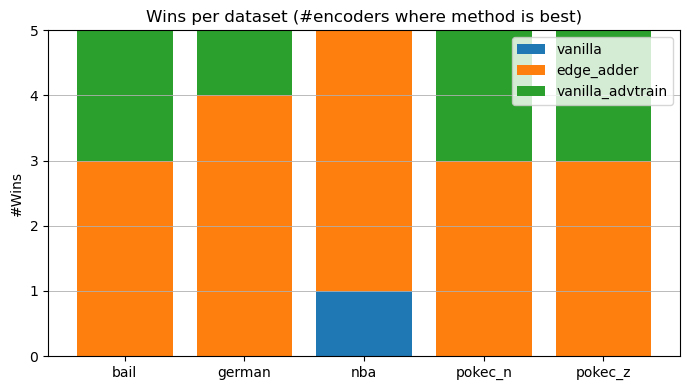

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

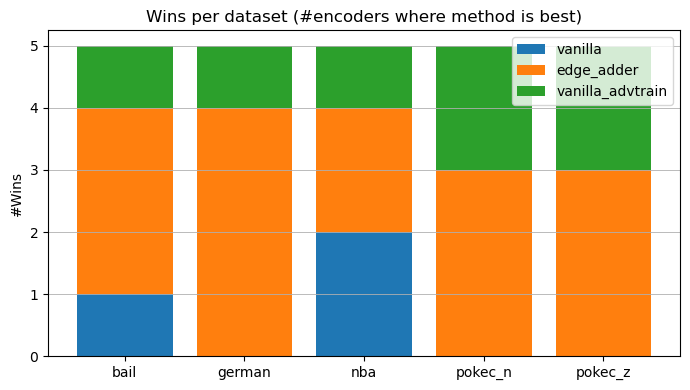

In [ ]:
metric = "EO_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

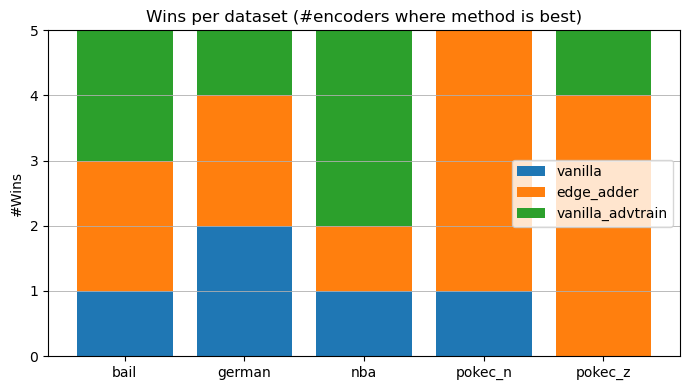

In [ ]:
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="max")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

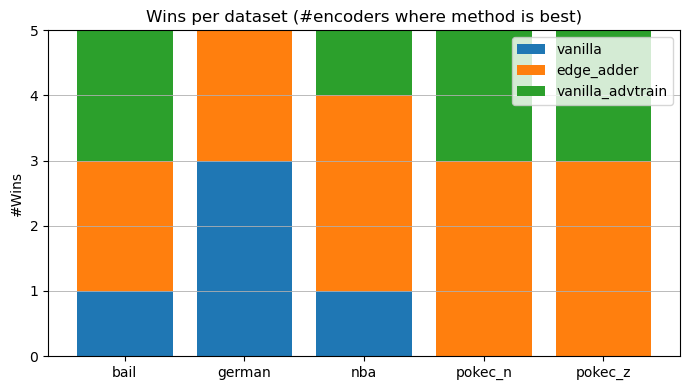

In [ ]:
metric = "AUC_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="max")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

### Trade-off Dot Charts

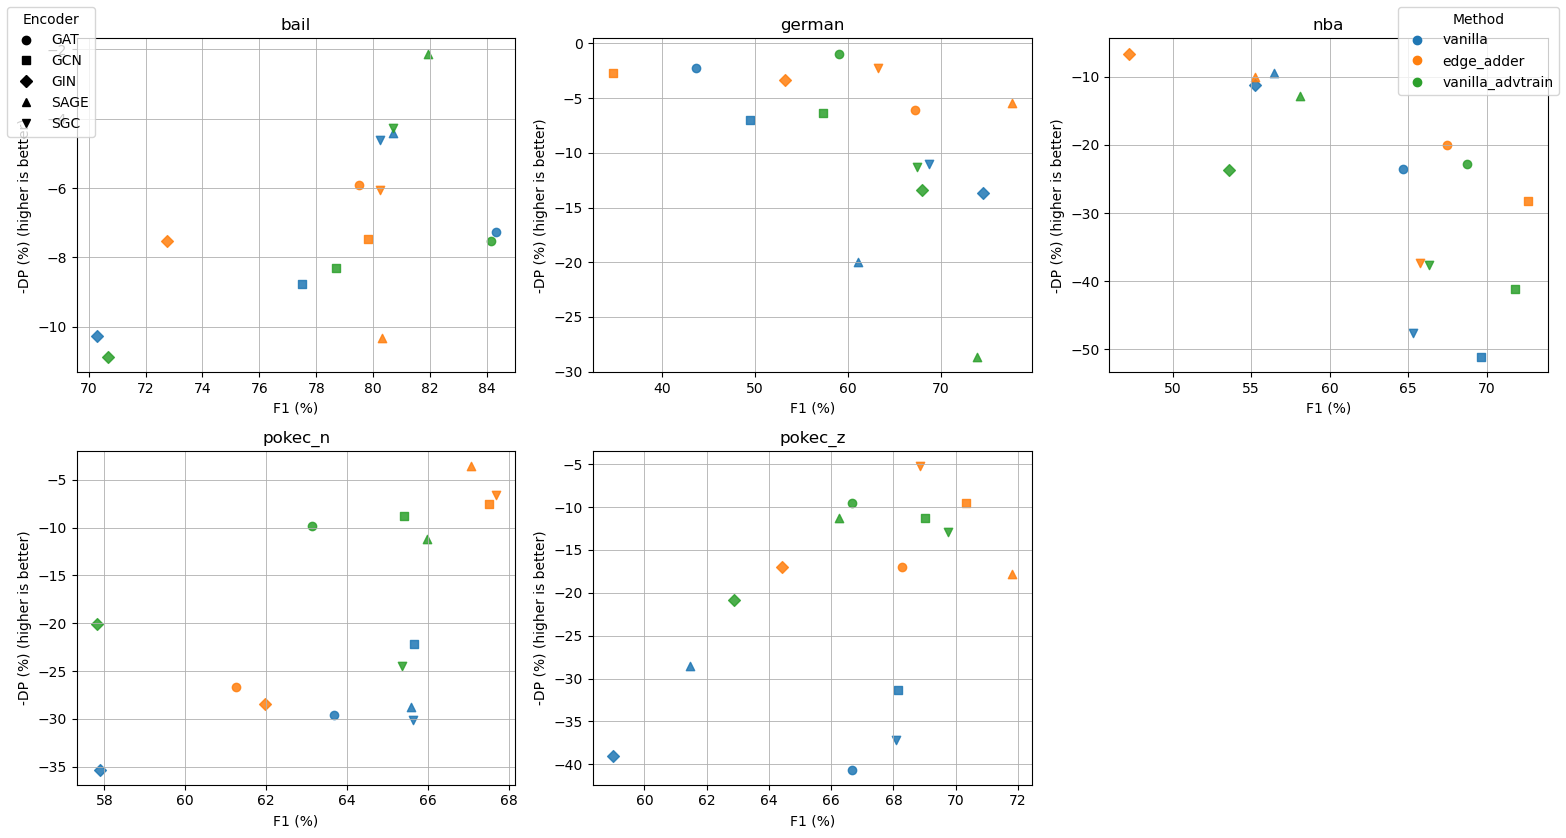

In [ ]:
pt_dp = (pts_attacked["DP_mean"] * 100).round(2)
pt_f1 = (pts_attacked["F1_mean"] * 100).round(2)   # adjust if your F1 is already in %

plot_fairness_utility_tradeoff(
    pt_fair=pt_dp,
    pt_util=pt_f1,
    fairness_label="DP (%)",
    utility_label="F1 (%)",
    better_fairness="min",
    ncols=3
)
plt.show()

# 08 Feb 2026 - k=4 with lambda_dp = lambda_eo = 1.0

## Test split (attacked)

In [95]:
EXP_DIR = "../logs/compare_expB_k-2_lambda_DP-1.0_lambda_EO-1.0"

In [106]:
df_attacked_adv = collect_results_among_seeds(EXP_DIR, verbose=True)
df_attacked_adv.shape

(25, 17)

In [107]:
df_baseline = pd.read_csv("./df_compare_vanilla_ea.csv")
df_baseline.shape

(50, 17)

In [108]:
df_attacked = pd.concat([df_baseline, df_attacked_adv], ignore_index=True)
df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_attacked.shape

(75, 17)

In [110]:
C_10seeds = df_attacked["n_seeds"] == 10
df_attacked[C_10seeds].shape

(75, 17)

In [136]:
tmp = collect_test_clean_metrics_from_seeds(EXP_DIR, split_name="test")
tmp = aggregate_over_seeds(tmp)
tmp.shape

(25, 22)

In [111]:
df_test_clean_seed = collect_test_clean_metrics_from_seeds(EXP_DIR, split_name="test_clean")
df_test_clean_seed.shape

(250, 13)

In [112]:
# Aggregate mean/std/count over seeds for each (method, dataset, encoder, model, timestamp)
df_test_clean_agg = aggregate_over_seeds(df_test_clean_seed)
df_test_clean_agg.shape

(25, 22)

In [113]:
pts_attacked = {}

In [114]:
metric = "DP_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            7.26   8.76  10.28   4.42   4.62
        edge_adder         5.92   7.46   7.54  10.34   6.06
        vanilla_advtrain   7.28   8.34  10.55   3.24   3.50
german  vanilla            2.28   6.97  13.69  19.94  11.05
        edge_adder         6.06   2.71   3.31   5.44   2.29
        vanilla_advtrain   0.00   7.67   7.84  19.29  10.21
nba     vanilla           23.54  51.12  11.24   9.43  47.54
        edge_adder        20.05  28.24   6.62  10.03  37.32
        vanilla_advtrain  26.52  45.59  18.52  11.71  39.50
pokec_n vanilla           29.61  22.13  35.31  28.78  30.12
        edge_adder        26.70   7.52  28.43   3.55   6.59
        vanilla_advtrain   8.02  10.29  26.63  11.15  23.70
pokec_z vanilla           40.60  31.37  39.02  28.48  37.10
        edge_adder        16.95   9.57  17.01  17.77   5.23
        vanilla_advtrain   3.73   3.61  18.12   6.14   5.92

In [115]:
metric = "EO_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla            4.91   4.30   6.43   1.76   2.70
        edge_adder         3.42   3.14   5.83   8.52   3.11
        vanilla_advtrain   4.76   4.08   6.47   1.71   2.20
german  vanilla            2.80   6.05  10.11  20.34  10.75
        edge_adder         7.44   2.17   4.88   2.63   1.97
        vanilla_advtrain   0.00   6.12   3.04  13.22   8.53
nba     vanilla           23.00  33.67   7.33   8.67  41.00
        edge_adder        22.00  13.00   8.67  10.00  26.33
        vanilla_advtrain  25.67  30.33  17.33   7.33  34.67
pokec_n vanilla           26.73  20.97  34.50  24.67  28.67
        edge_adder        23.70   7.36  24.71   1.97   5.83
        vanilla_advtrain   8.39  10.14  25.08  10.50  23.95
pokec_z vanilla           33.37  26.25  38.08  26.04  29.42
        edge_adder        14.66   8.23  17.42  14.92   4.64
        vanilla_advtrain   3.36   2.87  17.75   5.83   4.75

In [116]:
metric = "F1_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           84.30  77.51  70.28  80.69  80.23
        edge_adder        79.50  79.80  72.77  80.31  80.25
        vanilla_advtrain  83.11  78.31  72.41  81.11  80.85
german  vanilla           43.70  49.42  74.54  61.07  68.71
        edge_adder        67.20  34.74  53.19  77.59  63.26
        vanilla_advtrain  41.18  61.77  73.10  75.23  63.95
nba     vanilla           64.65  69.65  55.24  56.48  65.33
        edge_adder        67.45  72.63  47.24  55.27  65.75
        vanilla_advtrain  65.78  69.70  50.74  57.80  66.85
pokec_n vanilla           63.67  65.65  57.90  65.57  65.61
        edge_adder        61.25  67.51  61.97  67.06  67.66
        vanilla_advtrain  62.86  63.78  61.41  66.62  66.37
pokec_z vanilla           66.66  68.14  58.99  61.47  68.09
        edge_adder        68.27  70.32  64.42  71.80  68.85
        vanilla_advtrain  67.13  69.90  65.40  64.69  69.90

In [117]:
metric = "AUC_mean"
pts_attacked[metric] = df_attacked[C_10seeds].pivot_table(
    index=["dataset", "method"],
    columns=["encoder"],
    values=metric,
    observed=False
)
round(pts_attacked[metric] * 100, 2)

encoder                     gat    gcn    gin   sage    sgc
dataset method                                             
bail    vanilla           93.00  88.35  83.30  91.30  90.10
        edge_adder        90.12  89.45  83.90  90.23  89.70
        vanilla_advtrain  92.66  88.66  83.86  91.43  90.30
german  vanilla           50.38  55.60  70.76  67.37  60.06
        edge_adder        61.37  53.78  62.74  72.14  54.32
        vanilla_advtrain  51.43  54.73  69.87  71.87  59.66
nba     vanilla           66.88  71.59  60.67  65.28  73.46
        edge_adder        72.63  75.67  61.06  62.29  73.67
        vanilla_advtrain  71.47  75.62  59.81  64.58  74.04
pokec_n vanilla           69.78  74.11  62.96  68.22  72.52
        edge_adder        61.57  76.51  68.62  74.83  75.43
        vanilla_advtrain  74.98  75.14  68.71  73.76  73.98
pokec_z vanilla           70.57  75.58  66.32  69.90  74.09
        edge_adder        66.46  78.04  70.51  77.87  76.75
        vanilla_advtrain  75.24  77.34  71.13  75.18  75.51

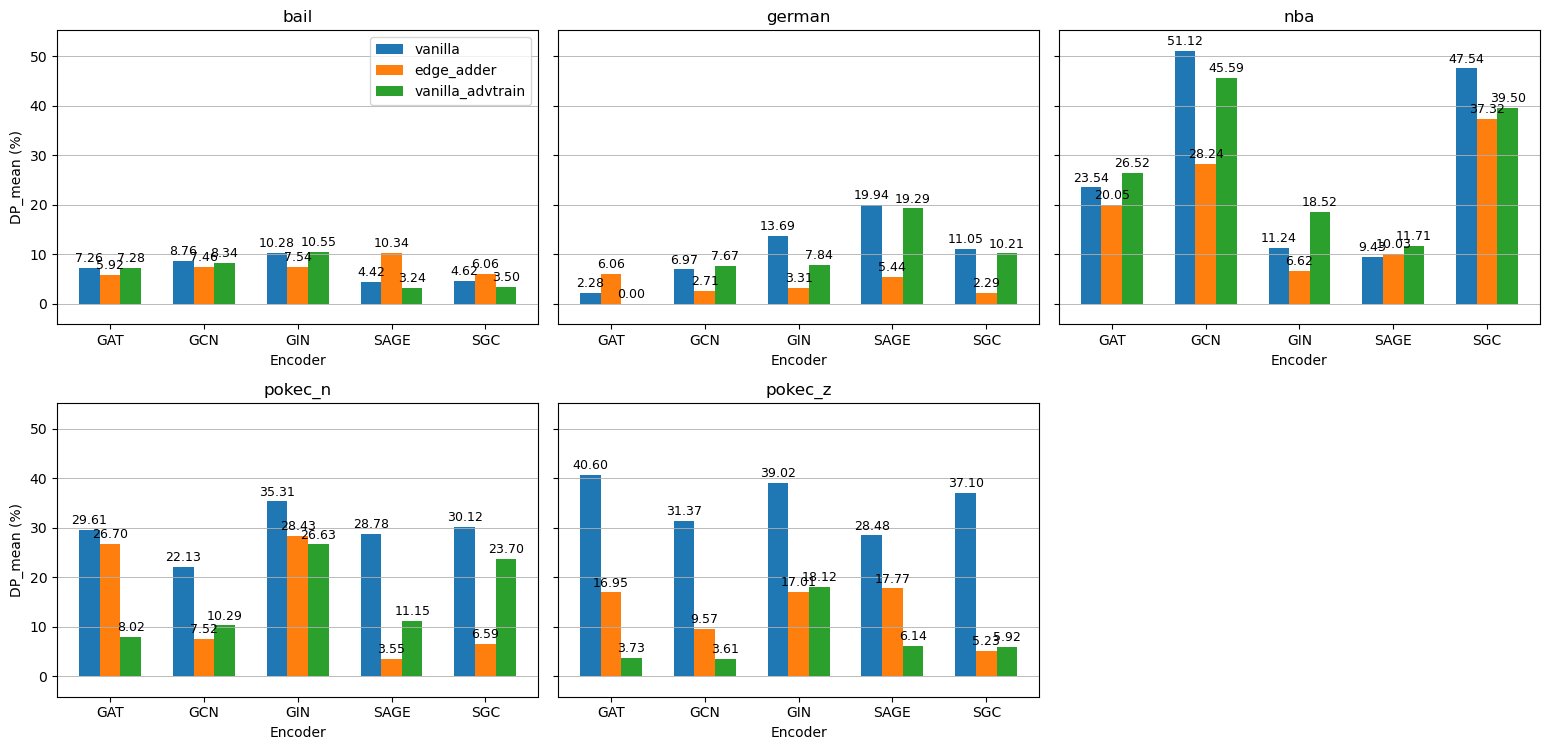

In [ ]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="DP (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

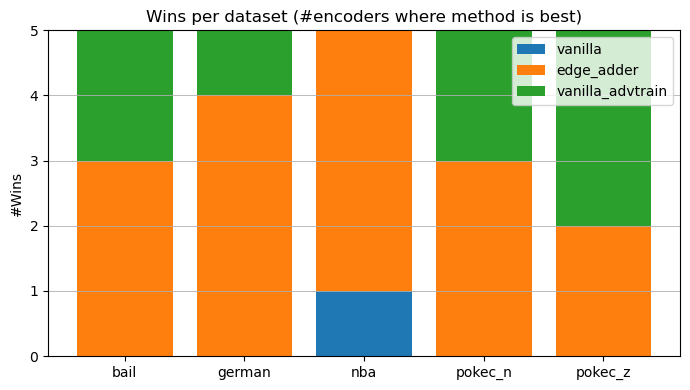

In [126]:
metric = "DP_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

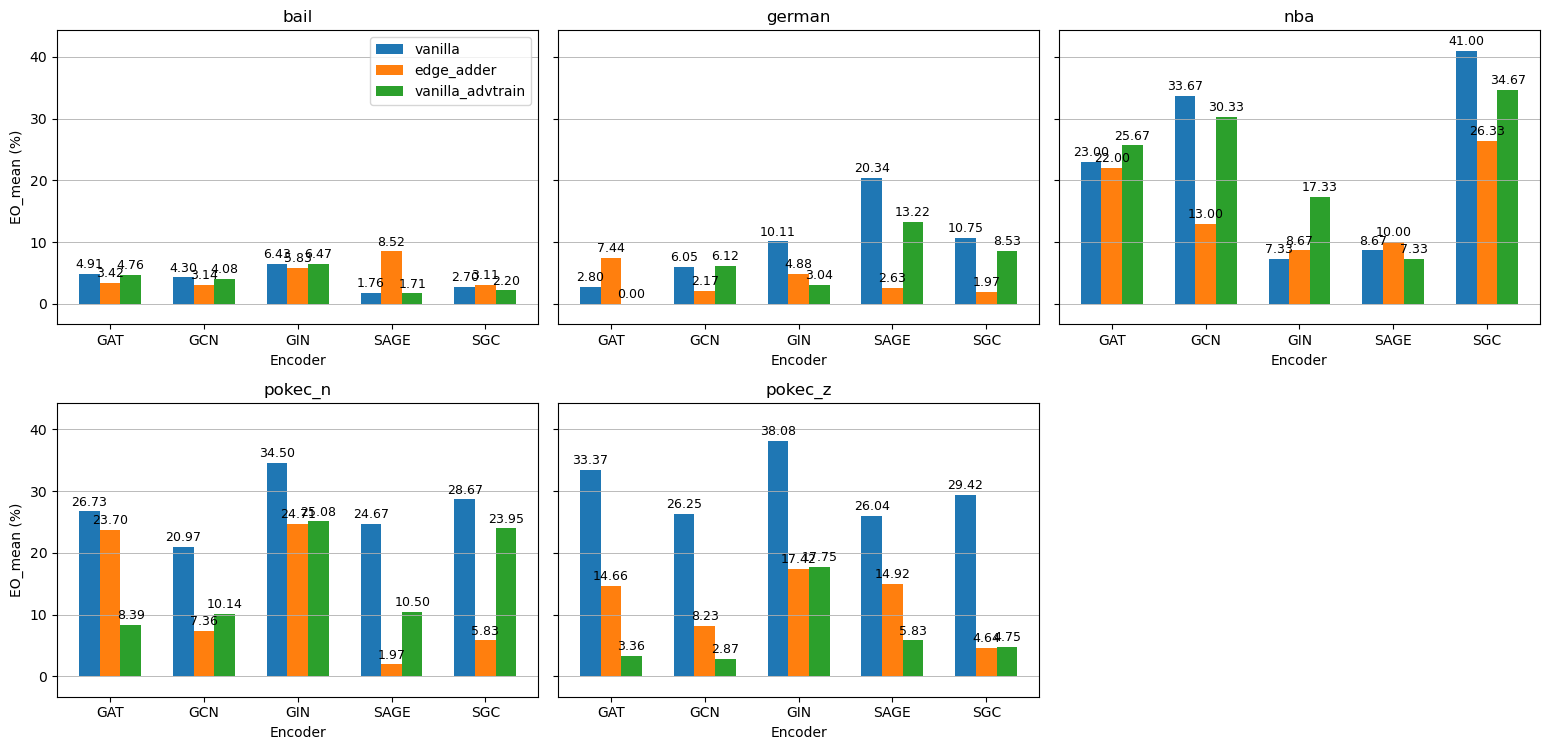

In [ ]:
metric = "EO_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "edge_adder", "vanilla_advtrain"),
    metric_label="EO (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

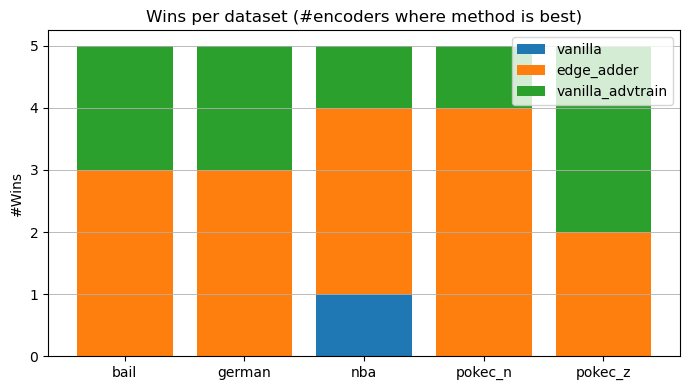

In [ ]:
metric = "EO_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

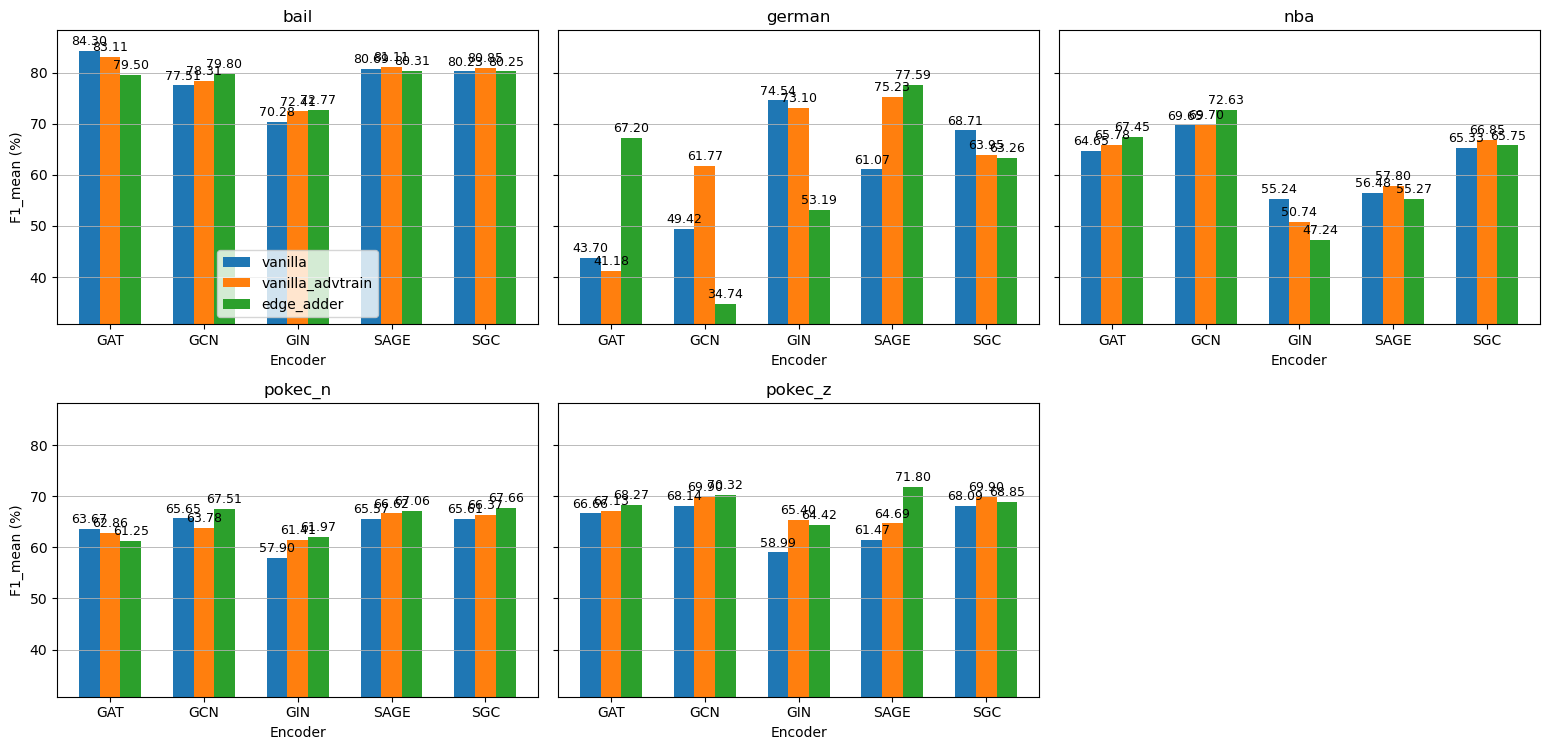

In [123]:
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "vanilla_advtrain", "edge_adder"),
    metric_label="F1_mean (%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

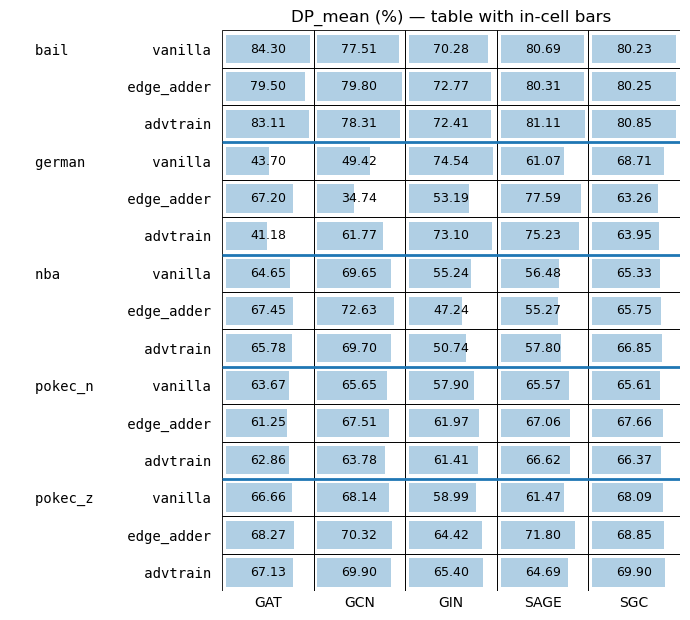

In [124]:
metric = "F1_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_table_with_bars(pt_percent, title="DP_mean (%) — table with in-cell bars", scale="col")
plt.show()

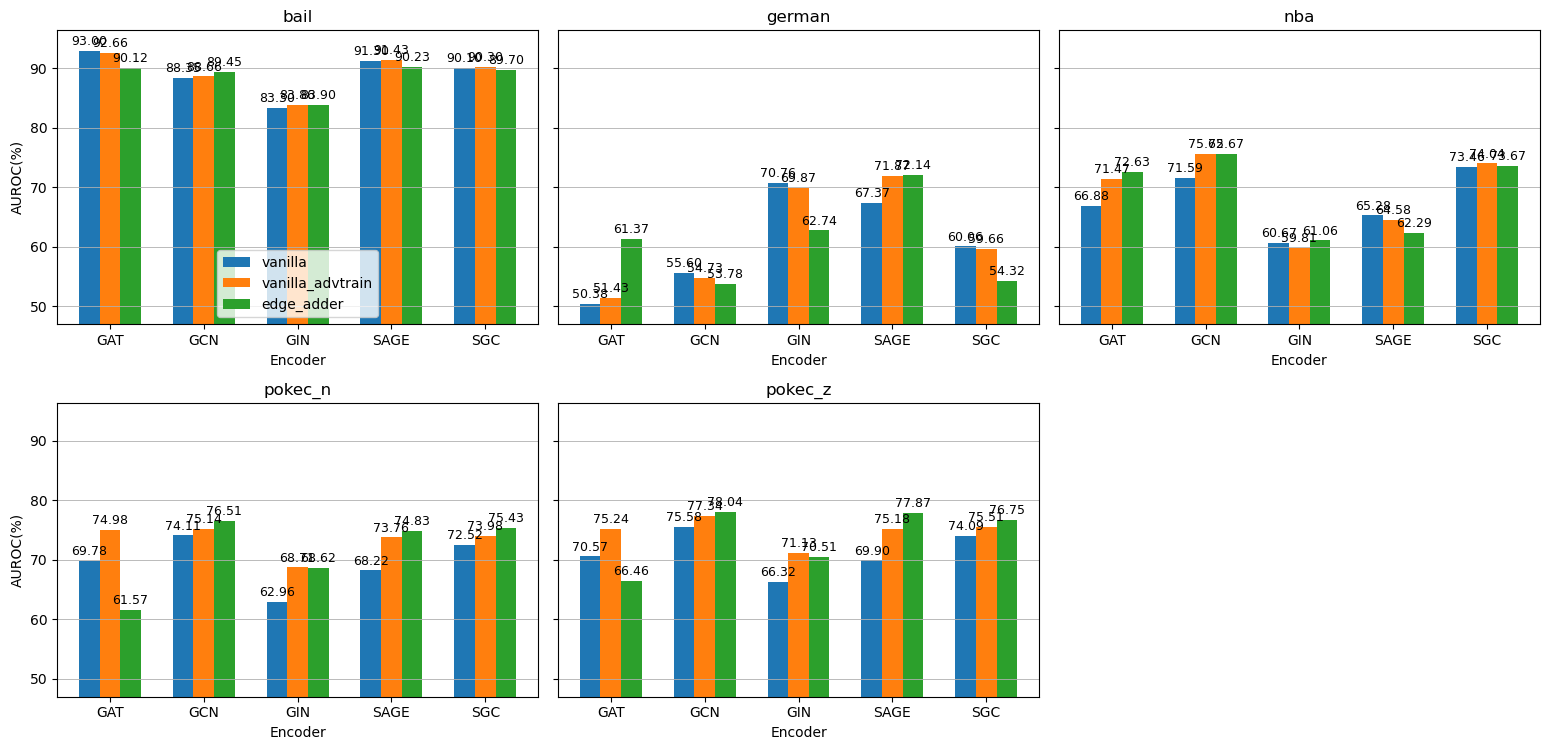

In [133]:
metric = "AUC_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

plot_grouped_bars_per_dataset(
    pt_percent,
    methods=("vanilla", "vanilla_advtrain", "edge_adder"),
    metric_label="AUROC(%)",
    ncols=3,
    rotate_xticks=0,
)
plt.show()

## Test clean split

In [5]:
fn = "./20260118/vanilla/df_vanilla_clean_and_tuned_nifa.csv"
df_baseline_vanilla = pd.read_csv(fn)
df_baseline_vanilla["method"] = "vanilla"

fn = "./20260118/ea/df_ea_clean_and_tuned_nifa.csv"
df_baseline_ea = pd.read_csv(fn)
df_baseline_ea["method"] = "edge_adder"

df_baseline = pd.concat([
    df_baseline_vanilla[df_baseline_vanilla["attack_mode"] == "no_attack"],
    df_baseline_ea[df_baseline_ea["attack_mode"] == "no_attack"]
], ignore_index=True)
df_baseline["method"] = pd.Categorical(df_baseline["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_baseline.columns = [c.lower() for c in df_baseline.columns]
df_baseline.shape


(50, 16)

In [6]:
exp_dir = "compare_expB_k-2_lambda_DP-1.0_lambda_EO-1.0"
fn = f"./adv/{exp_dir}/aggregated_results_test_clean.csv"
df_clean_adv = pd.read_csv(fn)
df_clean_adv.shape

(25, 22)

In [7]:
df_clean = pd.concat([df_baseline, df_clean_adv], ignore_index=True)
df_clean["method"] = pd.Categorical(df_clean["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_clean.shape

(75, 24)

In [8]:
df_clean["method"].value_counts()

method
vanilla             25
edge_adder          25
vanilla_advtrain    25
Name: count, dtype: int64

In [9]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}
pts_clean = {}

In [10]:
for metric in METRIC_KEYS:
    pt = df_clean.pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )
    pts_clean[metric] = pt

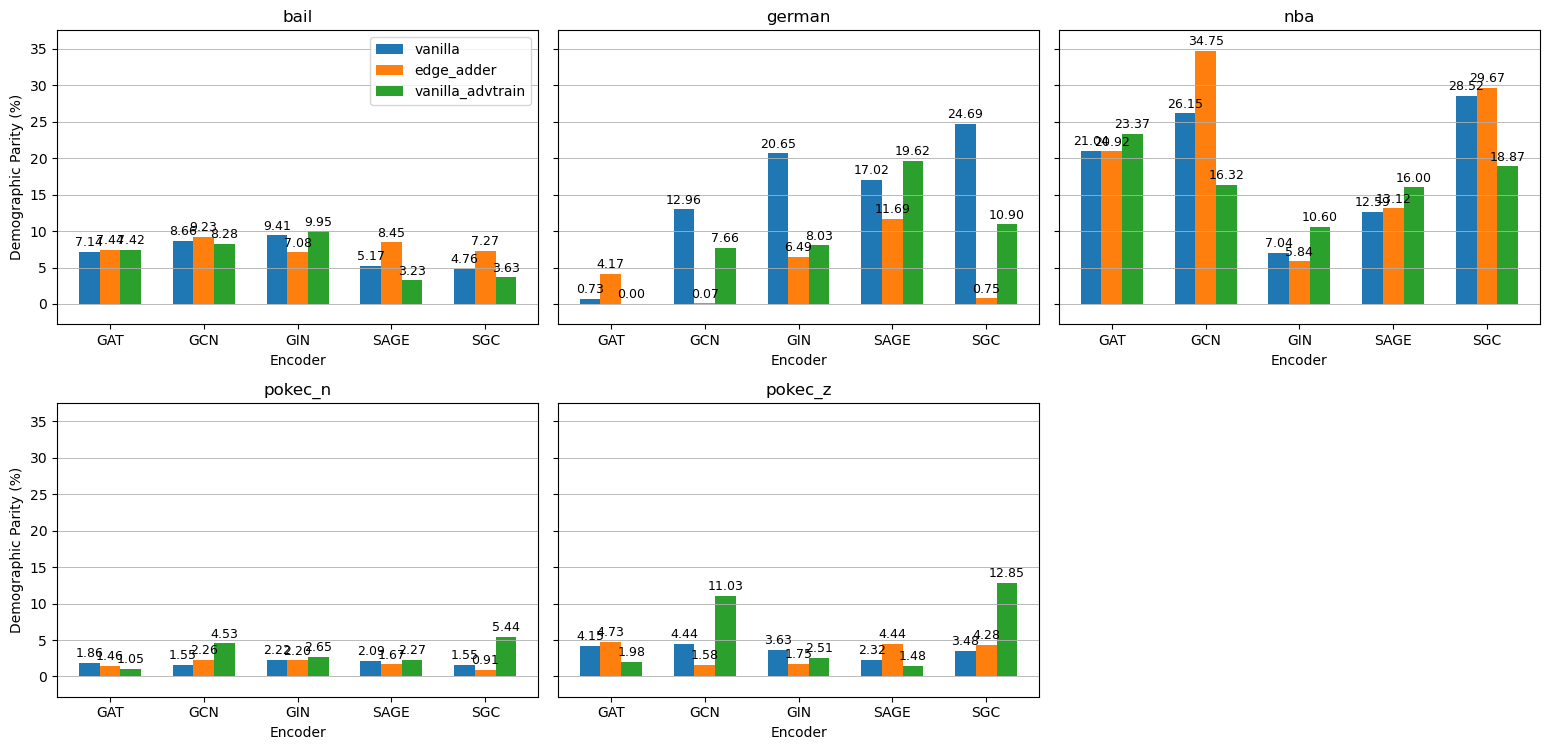

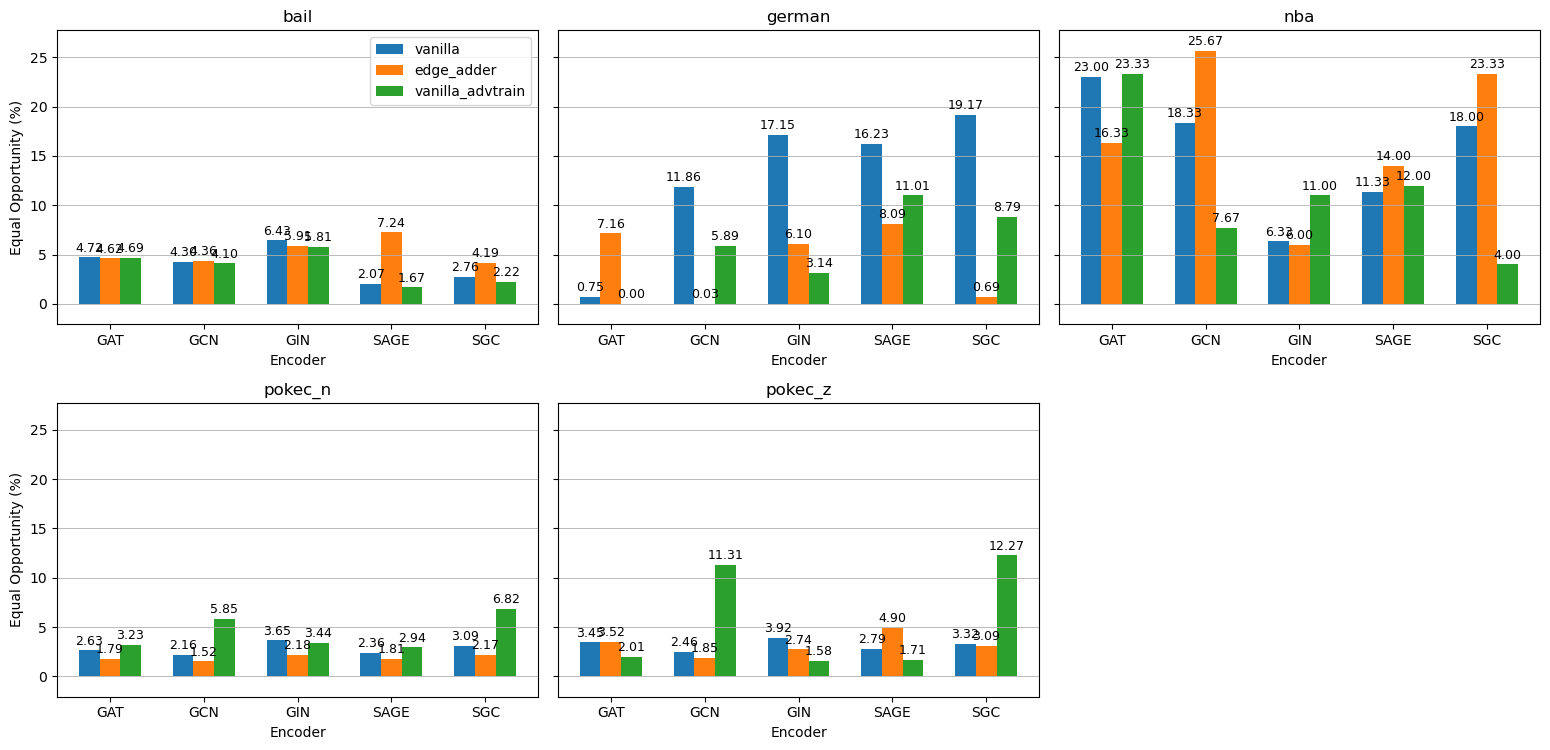

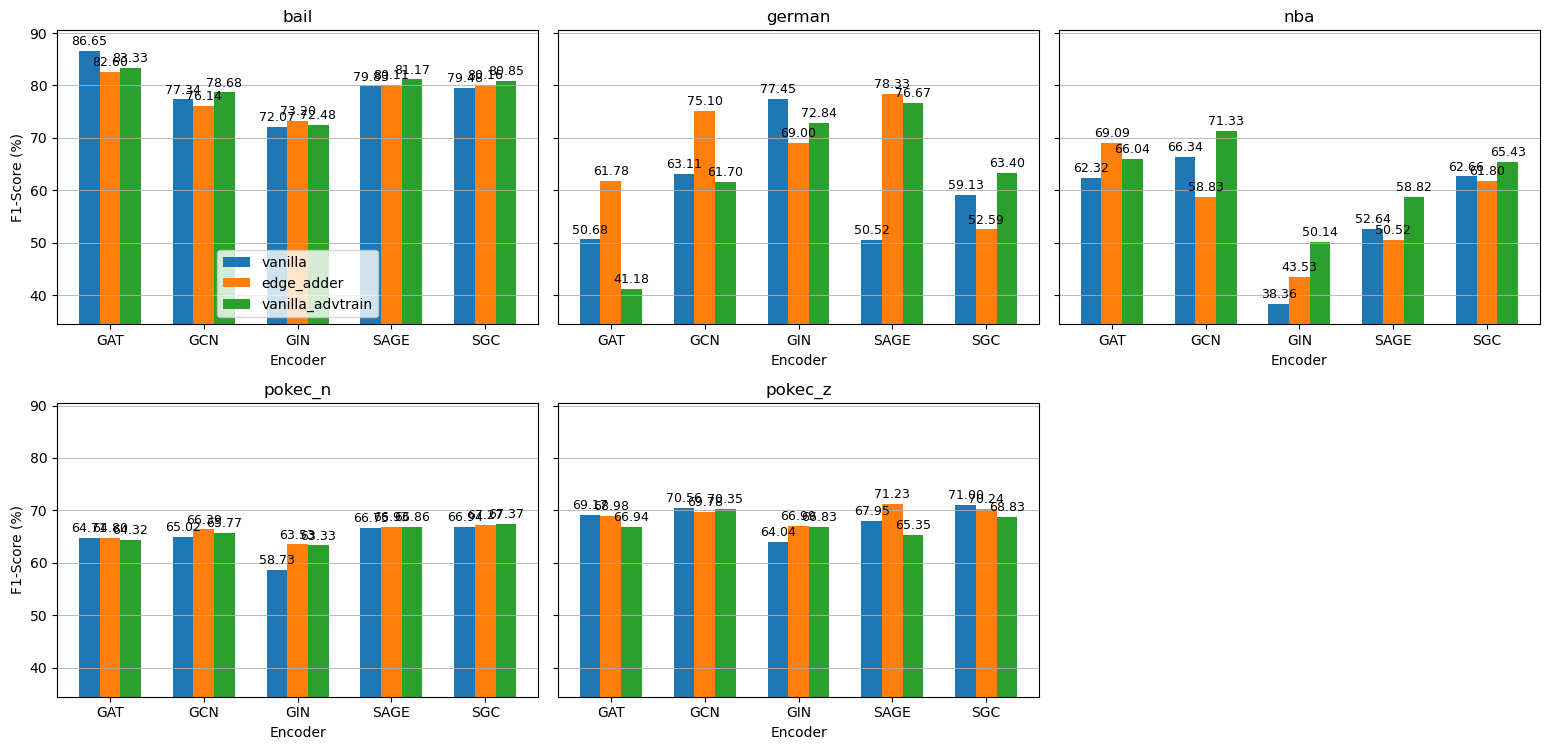

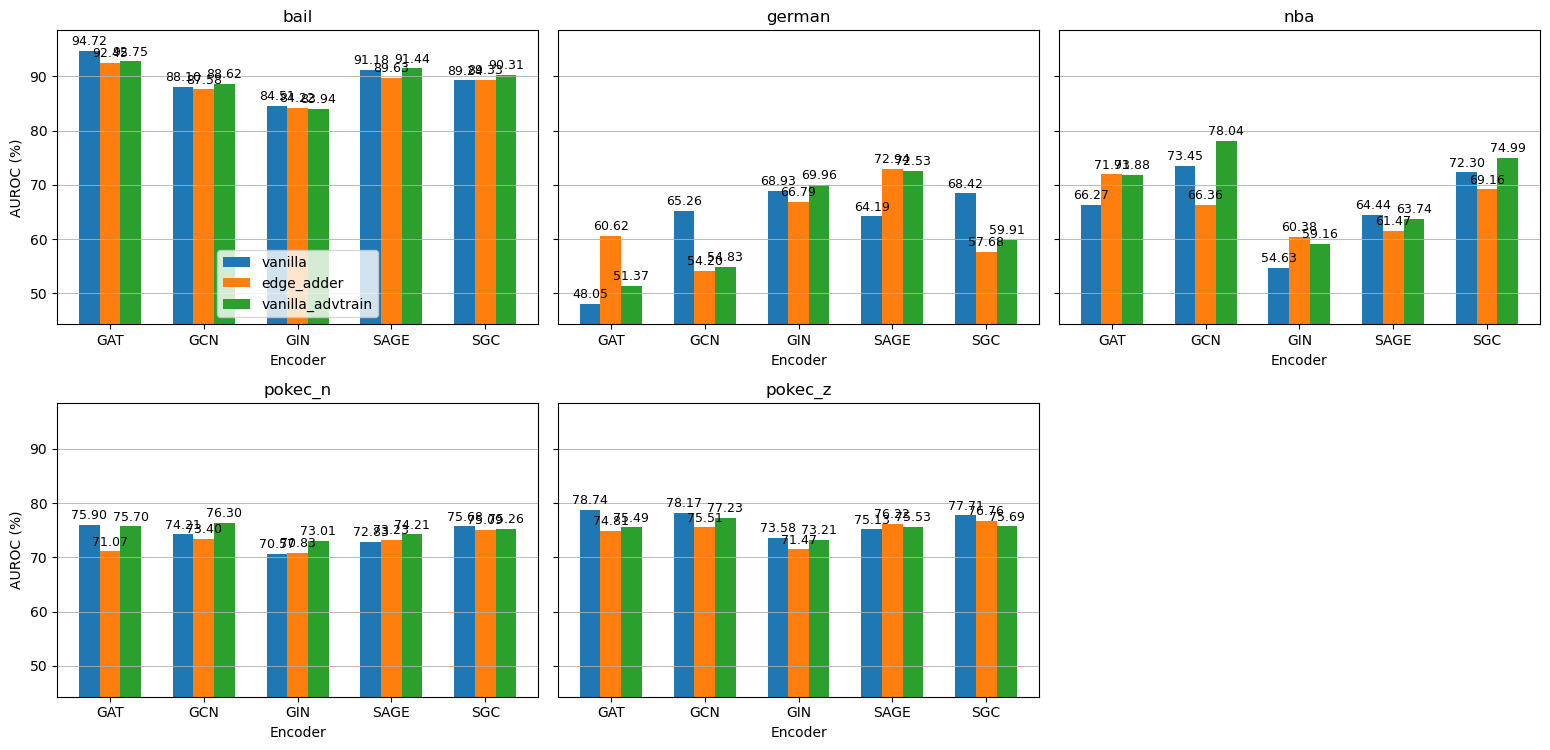

In [12]:
for metric in METRIC_KEYS:
    pt_percent = (pts_clean[metric] * 100).round(2)

    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=("vanilla", "edge_adder", "vanilla_advtrain"),
        metric_label=f"{MAP_METRIC_TO_LABEL.get(metric, metric.upper())} (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

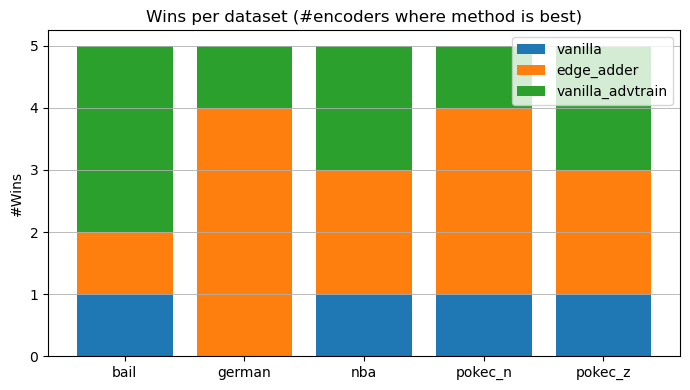

In [13]:
metric = "dp_mean"
pt_percent = (pts_clean[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

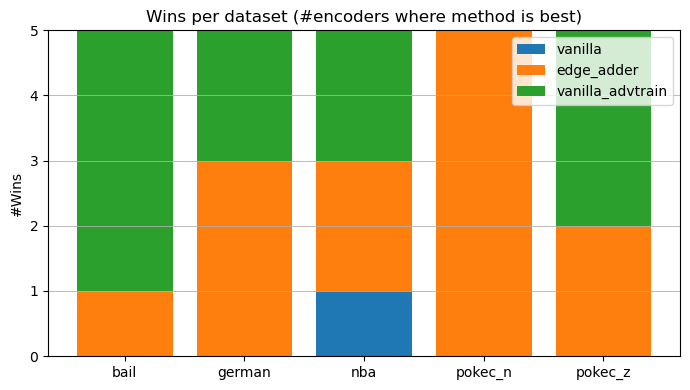

In [209]:
metric = "eo_mean"
pt_percent = (pts_clean[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

# 11 Feb 2026 - Different K values

In [14]:
fn = "./20260118/vanilla/df_vanilla_clean_and_tuned_nifa.csv"
df_baseline_vanilla = pd.read_csv(fn)
df_baseline_vanilla["method"] = "vanilla"

fn = "./20260118/ea/df_ea_clean_and_tuned_nifa.csv"
df_baseline_ea = pd.read_csv(fn)
df_baseline_ea["method"] = "edge_adder"

df_baseline = pd.concat([
    df_baseline_vanilla[df_baseline_vanilla["attack_mode"] == "no_attack"],
    df_baseline_ea[df_baseline_ea["attack_mode"] == "no_attack"]
], ignore_index=True)
df_baseline["method"] = pd.Categorical(df_baseline["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_baseline.columns = [c.lower() for c in df_baseline.columns]
df_baseline.shape

(50, 16)

In [16]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}

In [30]:
exp_folders=(
    "compare_expB_k-2_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-4_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-6_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-8_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-10_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-12_lambda_DP-1.0_lambda_EO-1.0",
    # "compare_expB_k-14_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-16_lambda_DP-1.0_lambda_EO-1.0",
)

In [31]:
def get_pts_clean(exp_dir: str):
    fn = f"./adv/{exp_dir}/aggregated_results_test_clean.csv"
    df_clean_adv = pd.read_csv(fn)
    df_clean = pd.concat([df_baseline, df_clean_adv], ignore_index=True)
    df_clean["method"] = pd.Categorical(df_clean["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)

    pts_clean = {}
    for metric in METRIC_KEYS:
        pt = df_clean.pivot_table(
            index=["dataset", "method"],
            columns=["encoder"],
            values=metric,
            observed=False
        )
        pts_clean[metric] = pt
    return pts_clean


In [32]:
pts_clean_ks = {}
for exp_dir in exp_folders:
    k = exp_dir.split('k-')[-1].split('_')[0]
    k = int(k)
    pts_clean_ks[k] = get_pts_clean(exp_dir)

In [33]:
pts_clean_ks.keys()

dict_keys([2, 4, 6, 8, 10, 12, 16])

### Visualization

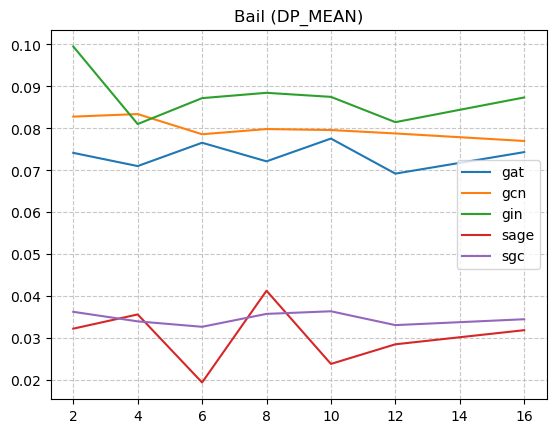

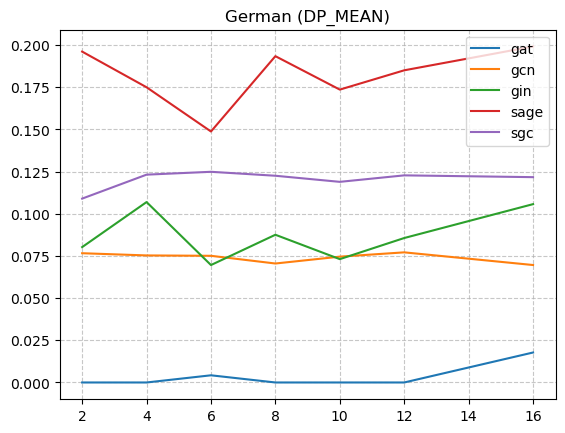

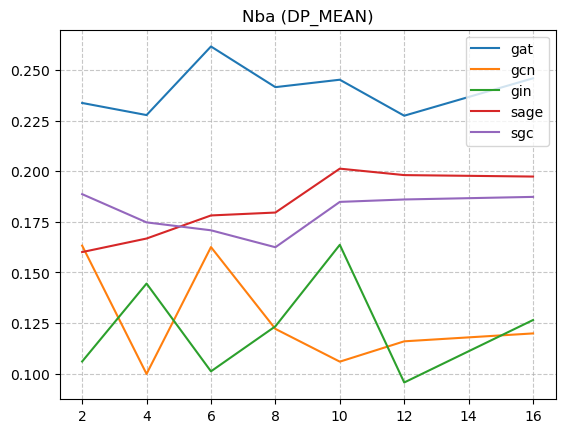

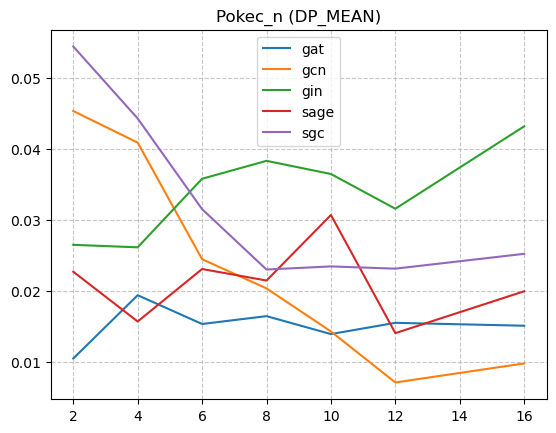

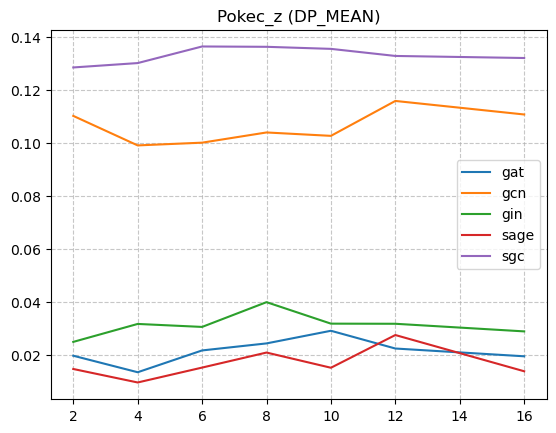

In [ ]:
metric = "dp_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_clean_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

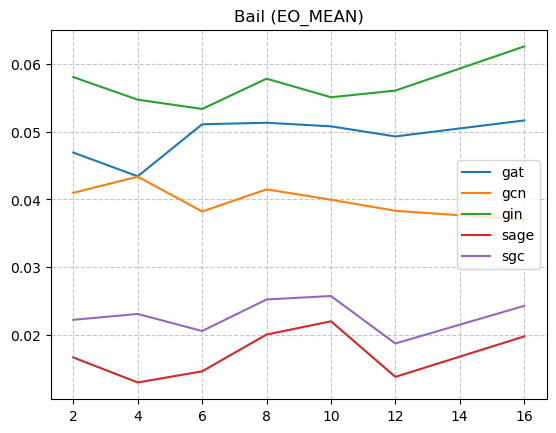

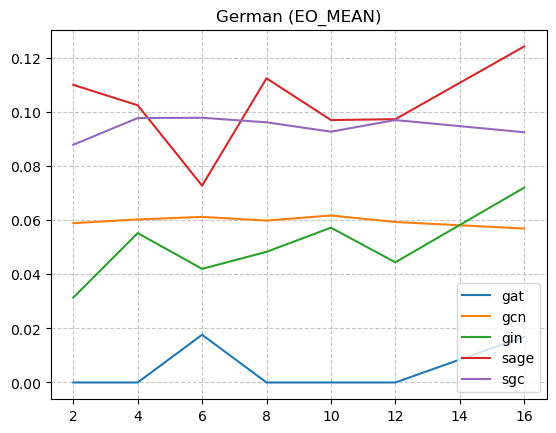

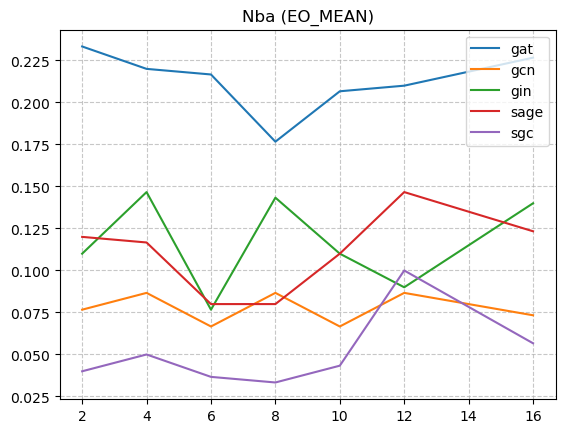

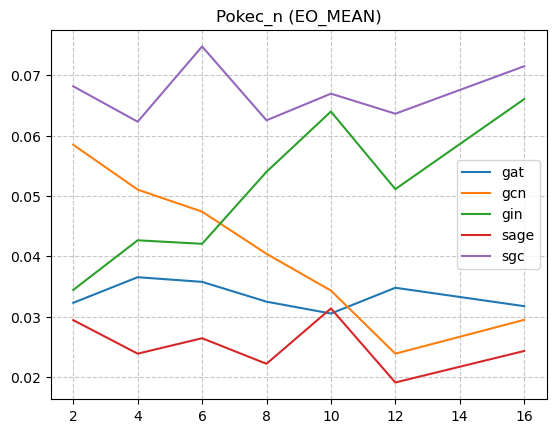

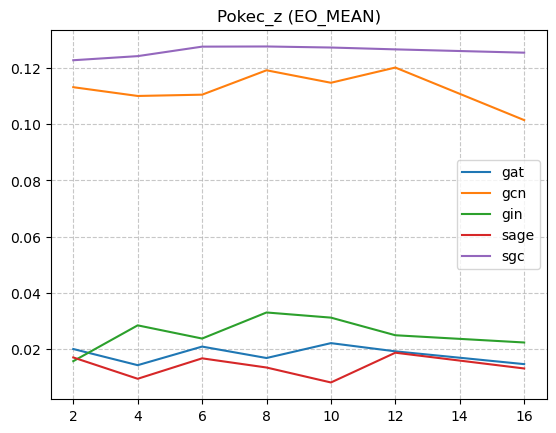

In [68]:
metric = "eo_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_clean_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

## Attacked

In [ ]:
exp_folders=(
    "compare_expB_k-2_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-4_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-6_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-8_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-10_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-12_lambda_DP-1.0_lambda_EO-1.0",
    # "compare_expB_k-14_lambda_DP-1.0_lambda_EO-1.0",
    "compare_expB_k-16_lambda_DP-1.0_lambda_EO-1.0",
)

In [77]:
def get_pts_attacked(exp_dir: str):
    fn = f"./adv/{exp_dir}/aggregated_results_test.csv"
    df_attacked_adv = pd.read_csv(fn)
    df_baseline = pd.read_csv("./df_compare_vanilla_ea.csv")
    df_attacked = pd.concat([df_baseline, df_attacked_adv], ignore_index=True)
    df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)

    pts_attacked = {}
    for metric in METRIC_KEYS:
        pt = df_attacked.pivot_table(
            index=["dataset", "method"],
            columns=["encoder"],
            values=metric,
            observed=False
        )
        pts_attacked[metric] = pt
    return pts_attacked


In [ ]:
pts_attacked_ks = {}
for exp_dir in exp_folders:
    k = exp_dir.split('k-')[-1].split('_')[0]
    k = int(k)
    pts_attacked_ks[k] = get_pts_attacked(exp_dir)

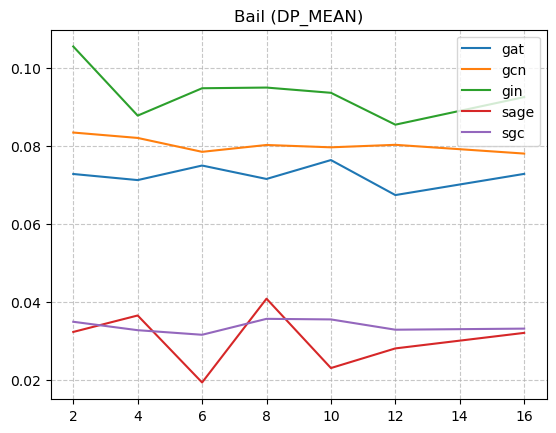

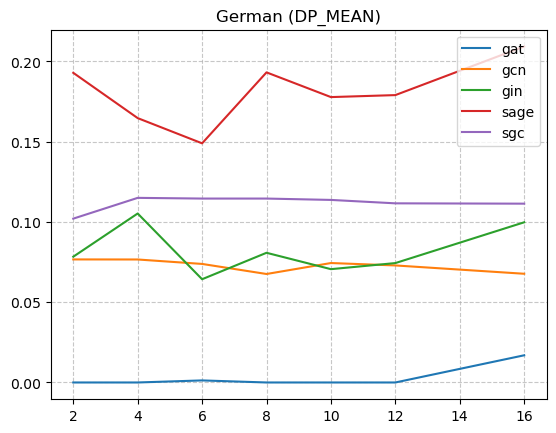

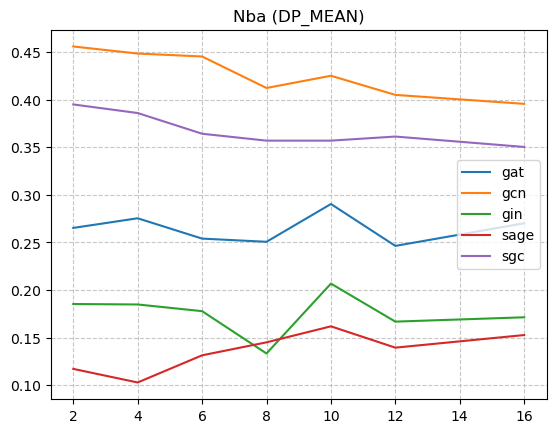

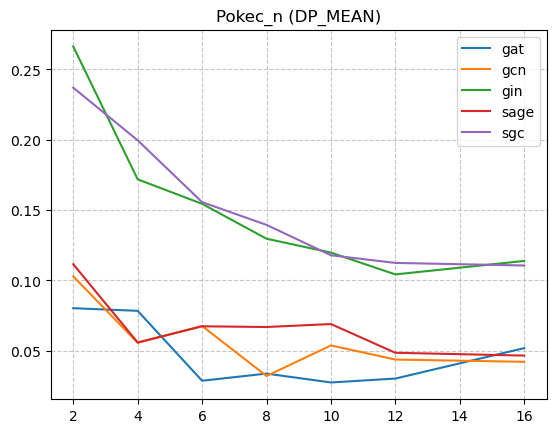

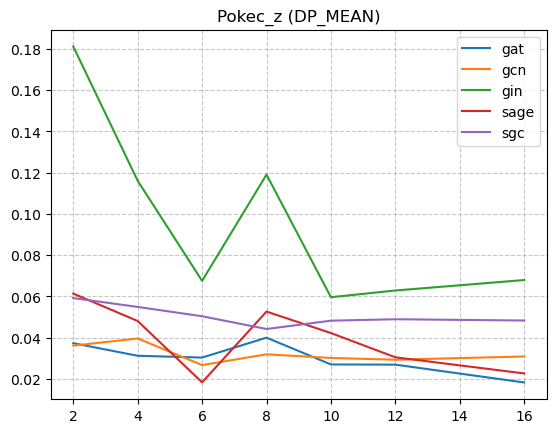

In [79]:
metric = "dp_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_attacked_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

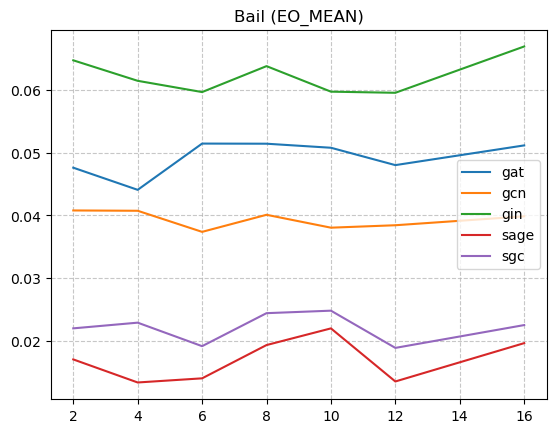

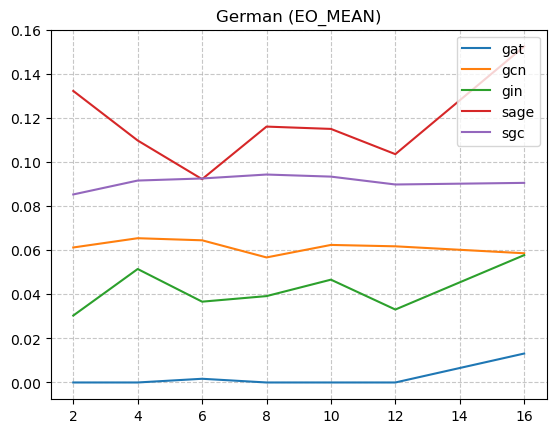

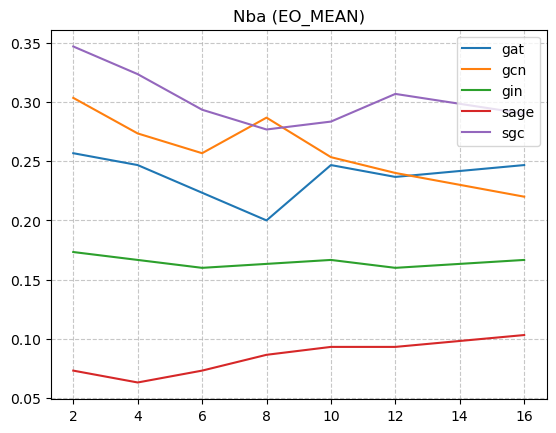

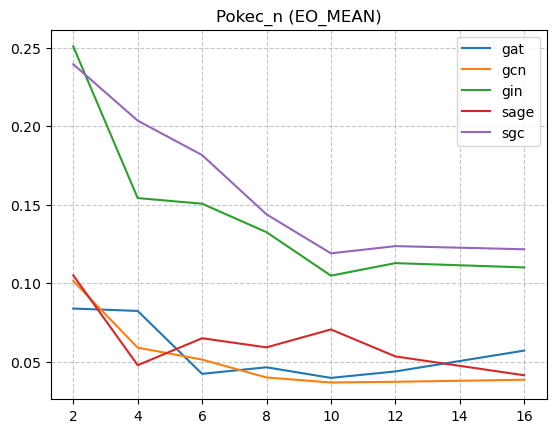

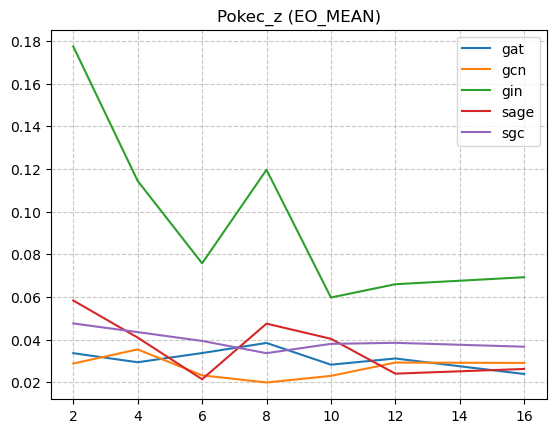

In [80]:
metric = "eo_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_attacked_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

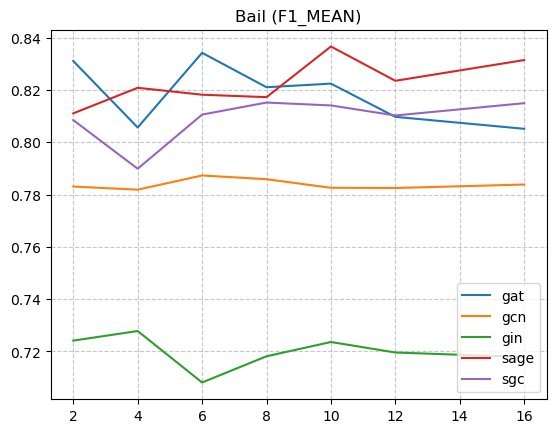

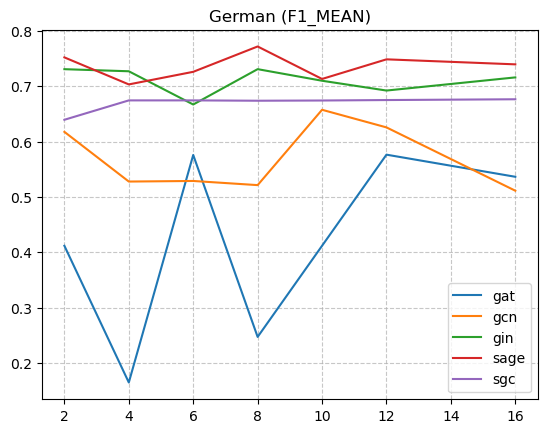

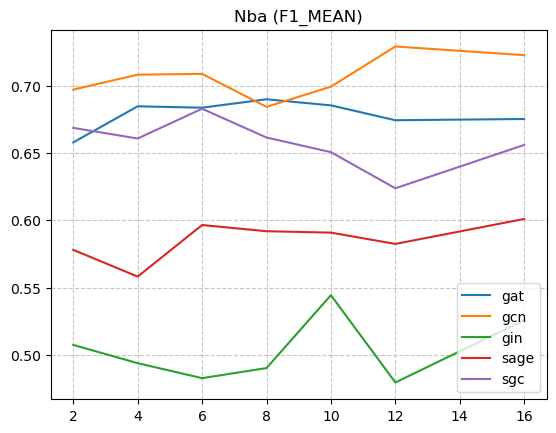

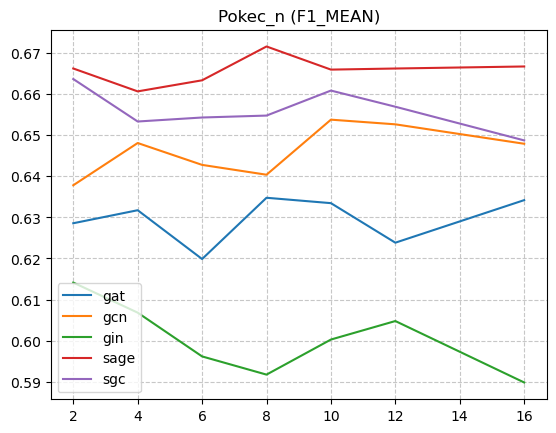

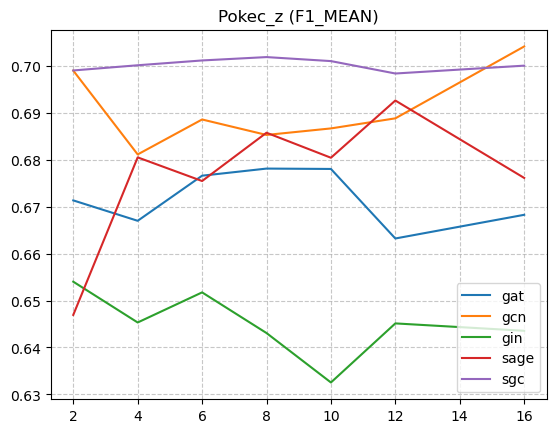

In [81]:
metric = "f1_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_attacked_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

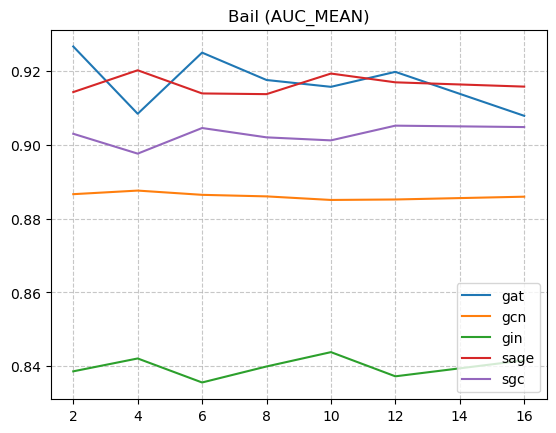

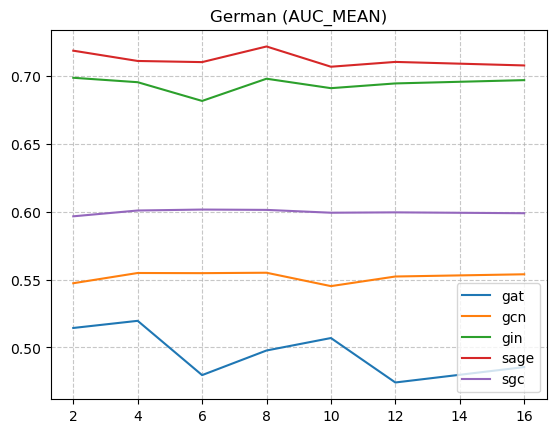

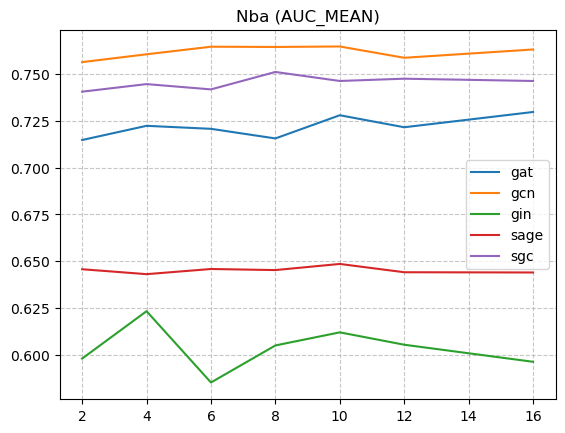

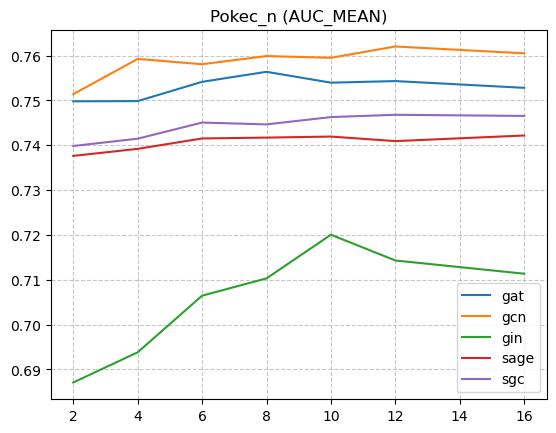

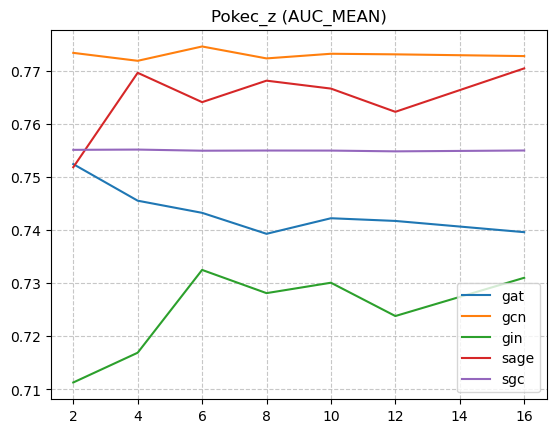

In [82]:
metric = "auc_mean"
for dataset in df_baseline["dataset"].unique():
    df = pd.DataFrame({k: v[metric].loc[(dataset, "vanilla_advtrain"), :] for k, v in pts_attacked_ks.items()}).T
    plt.plot(df, label=df.columns)
    #plt.hlines(y=pts_clean_ks[2][metric].loc[(dataset, "vanilla"), :], xmin=2, xmax=16)
    plt.grid(linestyle="--", alpha=0.7)
    plt.legend()
    plt.title(f"{dataset.capitalize()} ({metric.upper()})")
    plt.show()

# 02 Mar 2026 AdvTrain Edge - K=5 with lambda_dp = lambda_eo = 2.0, policy = same_smallest

## Test split (attacked)

In [26]:
EXP_DIR = "../logs/advtrain_edge/edge_weight_k-5_dp-2.0_eo-2.0_policy-same_smallest"
fn = os.path.join(EXP_DIR.split("logs/")[-1], "aggregated_results_test.csv")
df_attacked_adv = pd.read_csv(fn)
df_attacked_adv.shape

(25, 22)

In [34]:
df_baseline = pd.read_csv("./df_compare_vanilla_ea.csv")
df_baseline.shape

(50, 17)

In [38]:
df_attacked = pd.concat([df_baseline, df_attacked_adv])
df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain_edge_weight"], ordered=True)
df_attacked.shape

(75, 25)

In [40]:
pts_attacked = {}

In [45]:
METRICS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
for metric in METRICS:
    pts_attacked[metric] = df_attacked.pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )

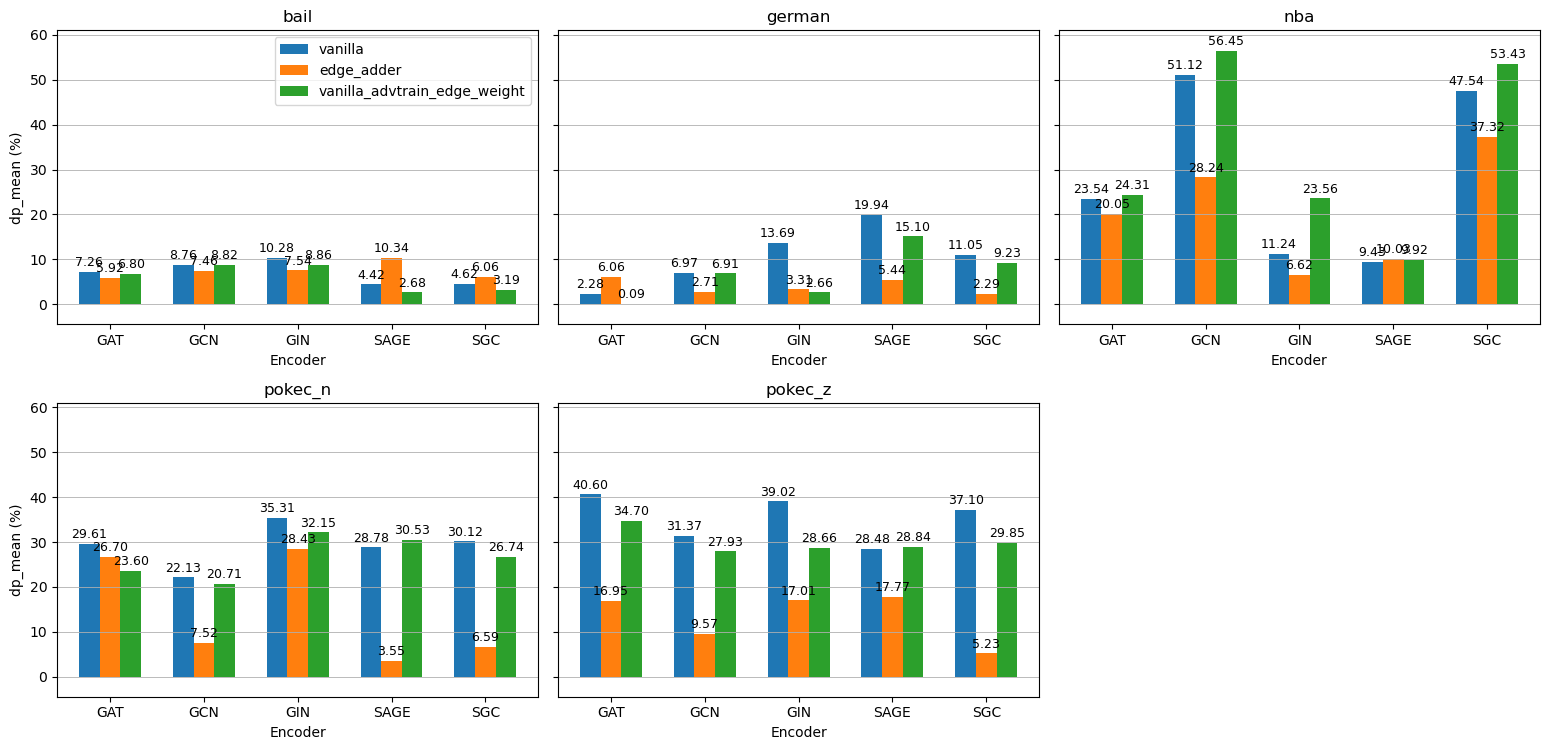

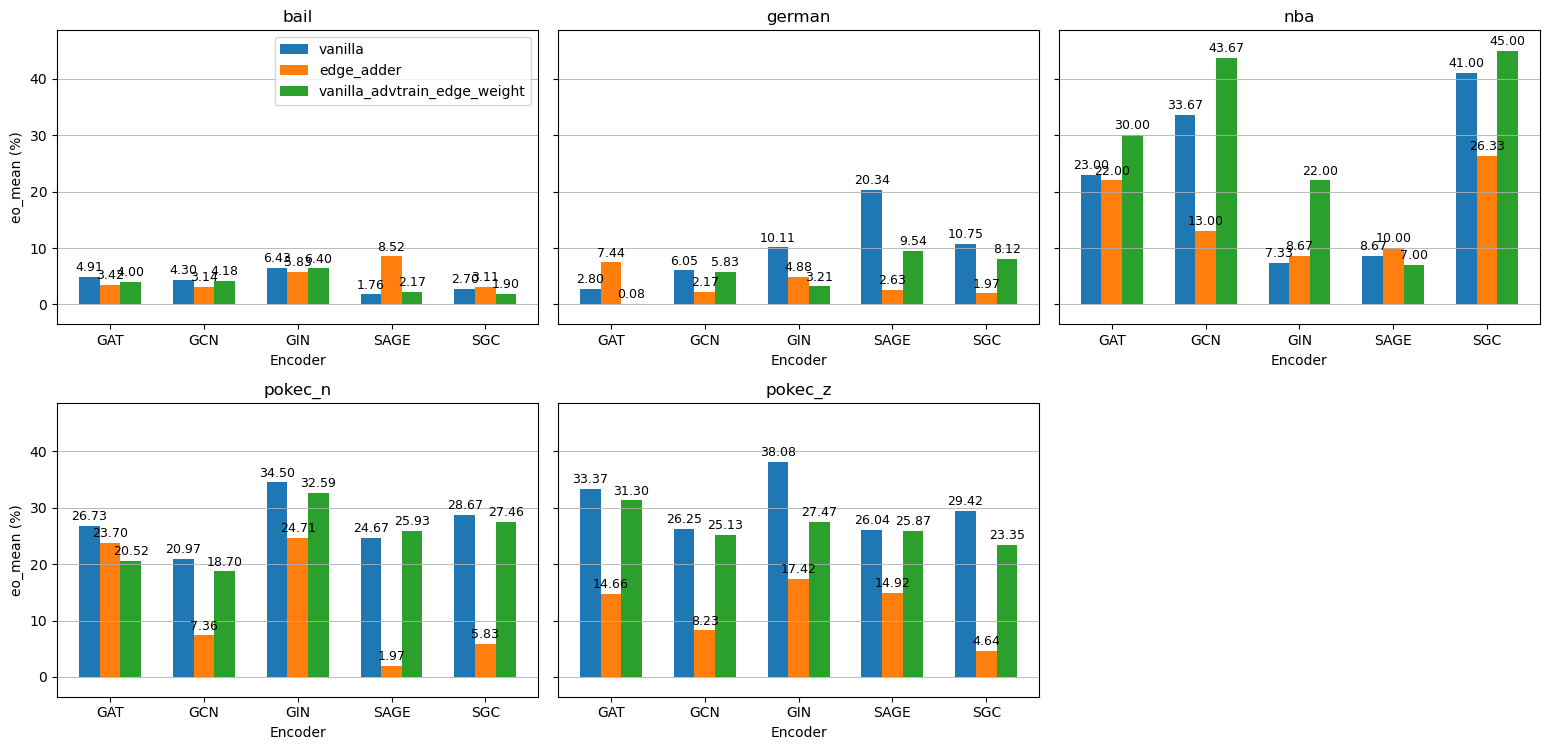

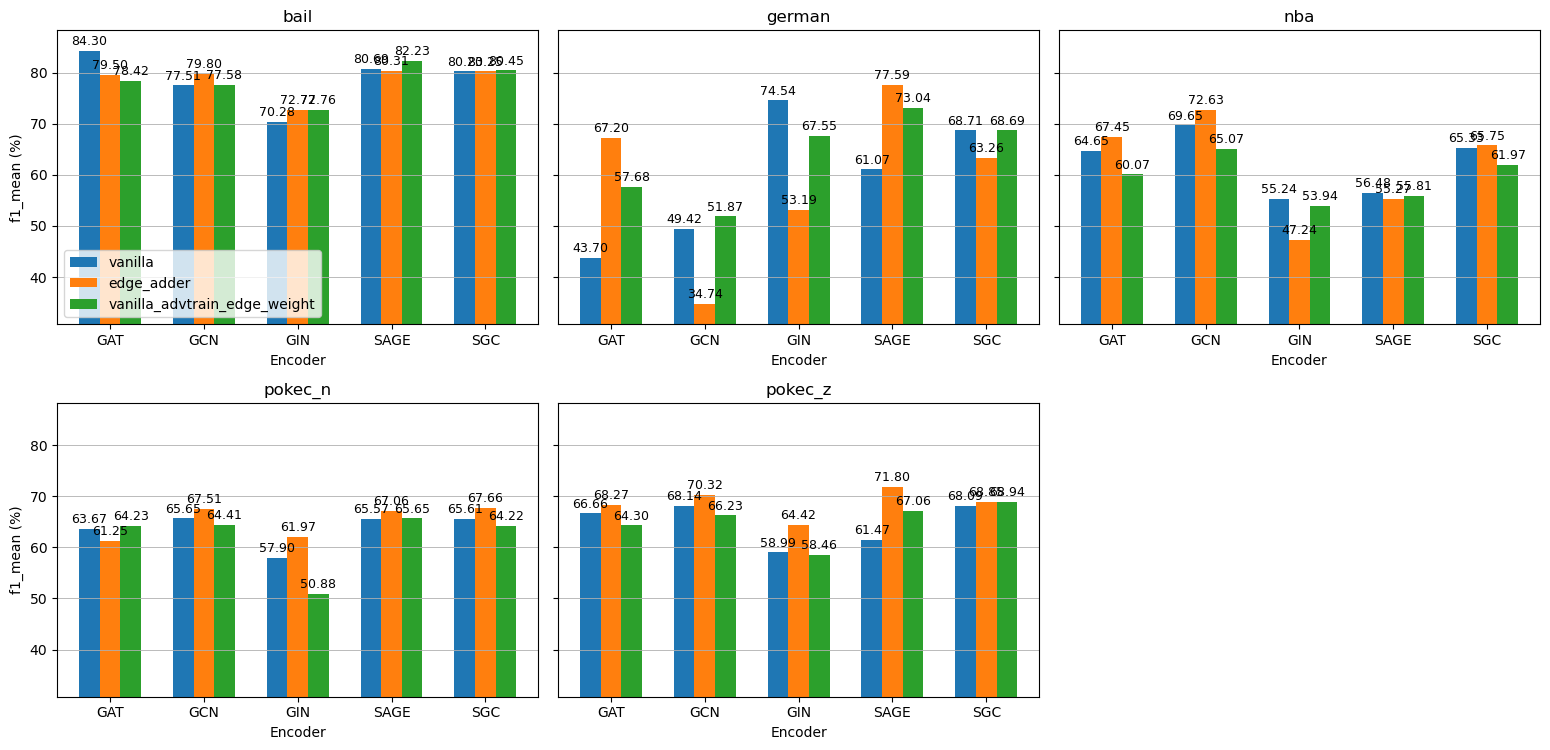

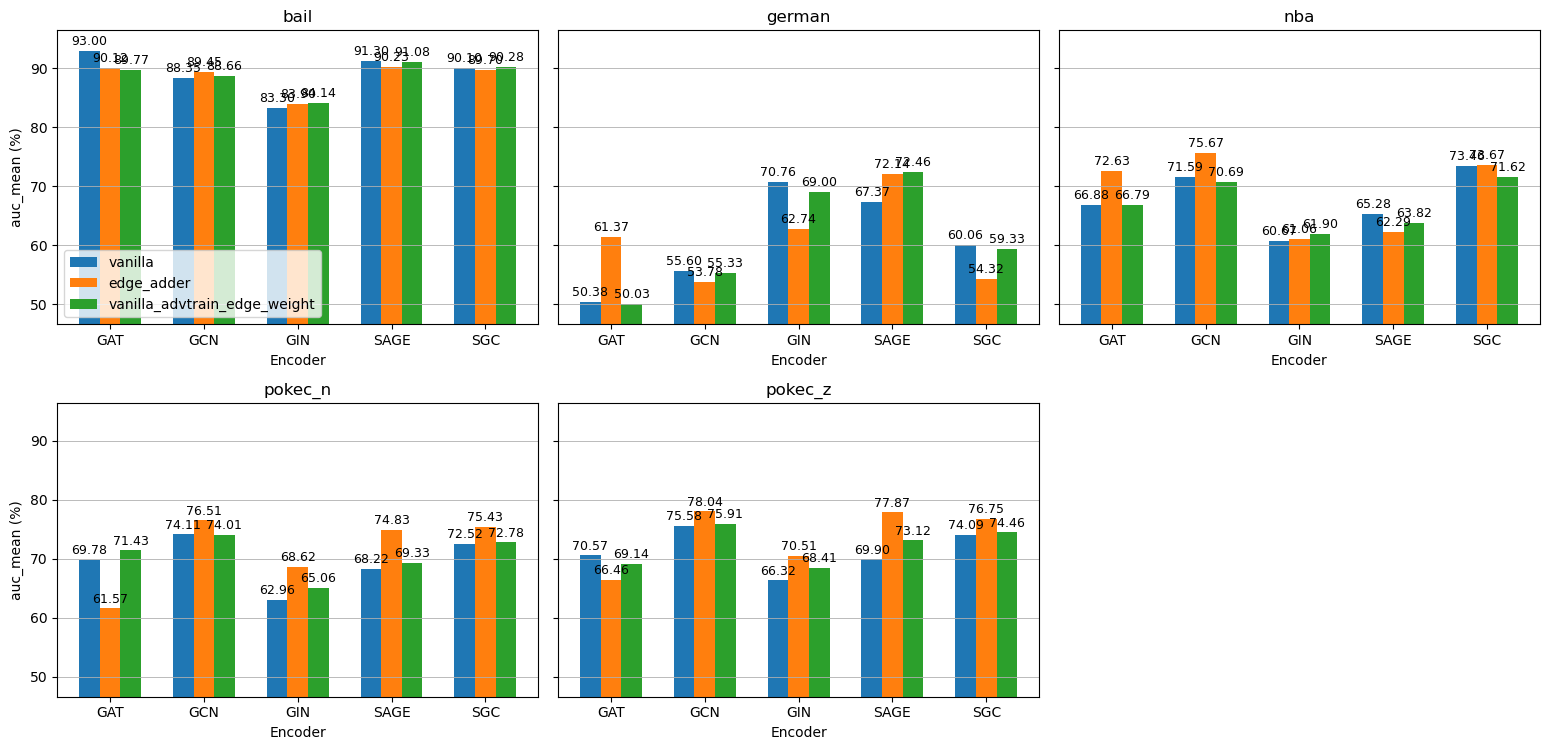

In [46]:
METRICS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
for metric in METRICS:
    pt_percent = (pts_attacked[metric] * 100).round(2)
    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=("vanilla", "edge_adder", "vanilla_advtrain_edge_weight"),
        metric_label=metric + " (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

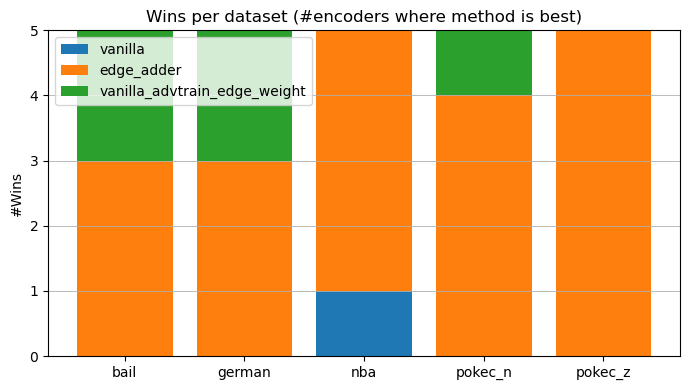

In [48]:
metric = "dp_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

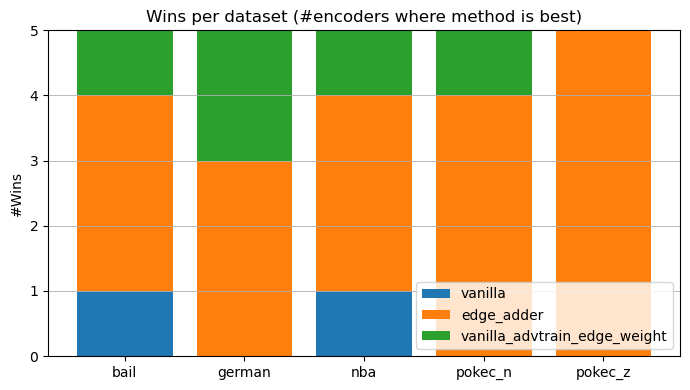

In [50]:
metric = "eo_mean"
pt_percent = (pts_attacked[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

# AdvTrain Edge - K=5 with different policies

## Test clean split

In [58]:
fn = "./20260118/vanilla/df_vanilla_clean_and_tuned_nifa.csv"
df_baseline_vanilla = pd.read_csv(fn)
df_baseline_vanilla["method"] = "vanilla"

fn = "./20260118/ea/df_ea_clean_and_tuned_nifa.csv"
df_baseline_ea = pd.read_csv(fn)
df_baseline_ea["method"] = "edge_adder"

df_baseline = pd.concat([
    df_baseline_vanilla[df_baseline_vanilla["attack_mode"] == "no_attack"],
    df_baseline_ea[df_baseline_ea["attack_mode"] == "no_attack"]
], ignore_index=True)
df_baseline["method"] = pd.Categorical(df_baseline["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_baseline.columns = [c.lower() for c in df_baseline.columns]
df_baseline.shape


(50, 16)

In [61]:
ROOT_RESULTS = "./advtrain_edge"
exp_folders=(
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-cross_random",
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-same_largest",
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-same_smallest"
)

lst_methods = ["vanilla", "edge_adder"]
lst_dfs = [df_baseline]
for exp_dir in exp_folders:
    policy = exp_dir.split("policy-")[-1]
    fn = f"{ROOT_RESULTS}/{exp_dir}/aggregated_results_test_clean.csv"
    df_clean_adv = pd.read_csv(fn)
    method = f"adv_edge_{policy}"
    df_clean_adv["method"] = method
    lst_methods.append(method)
    lst_dfs.append(df_clean_adv)

df_clean = pd.concat(lst_dfs, ignore_index=True)
df_clean["method"] = pd.Categorical(df_clean["method"], categories=lst_methods, ordered=True)
df_clean.shape

(125, 24)

In [62]:
df_clean["method"].value_counts()

method
vanilla                   25
edge_adder                25
adv_edge_cross_random     25
adv_edge_same_largest     25
adv_edge_same_smallest    25
Name: count, dtype: int64

In [63]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}
pts_clean = {}

In [64]:
for metric in METRIC_KEYS:
    pt = df_clean.pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )
    pts_clean[metric] = pt

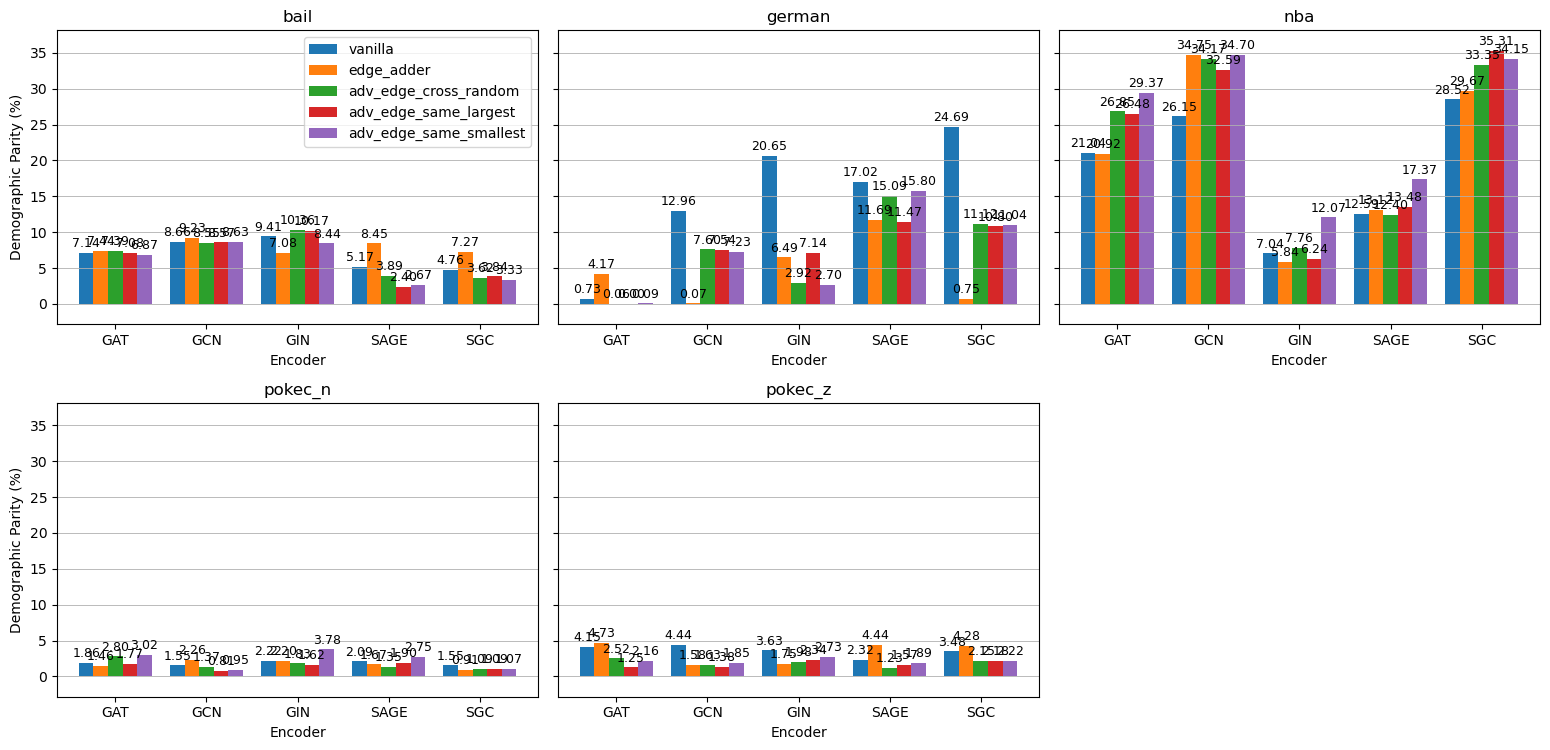

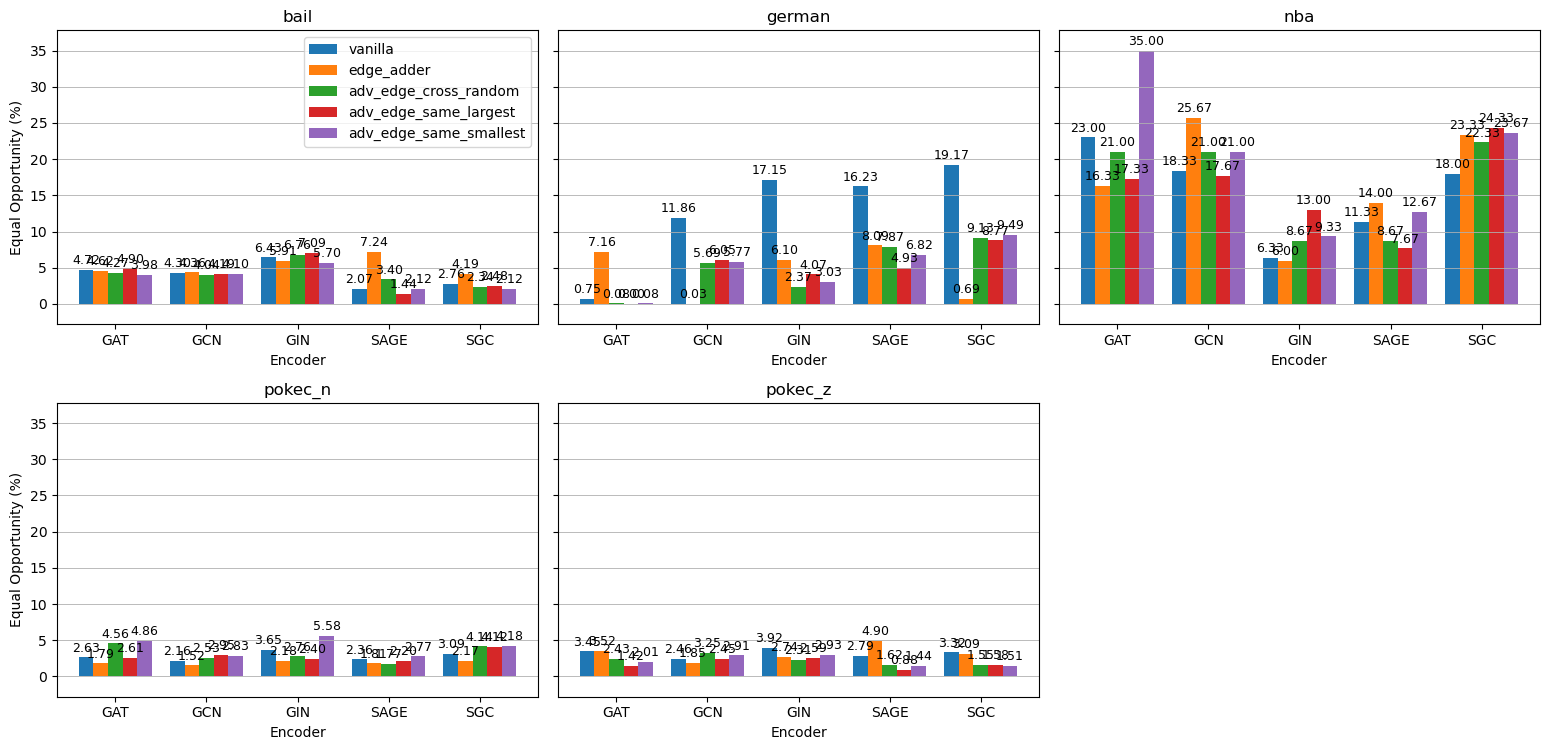

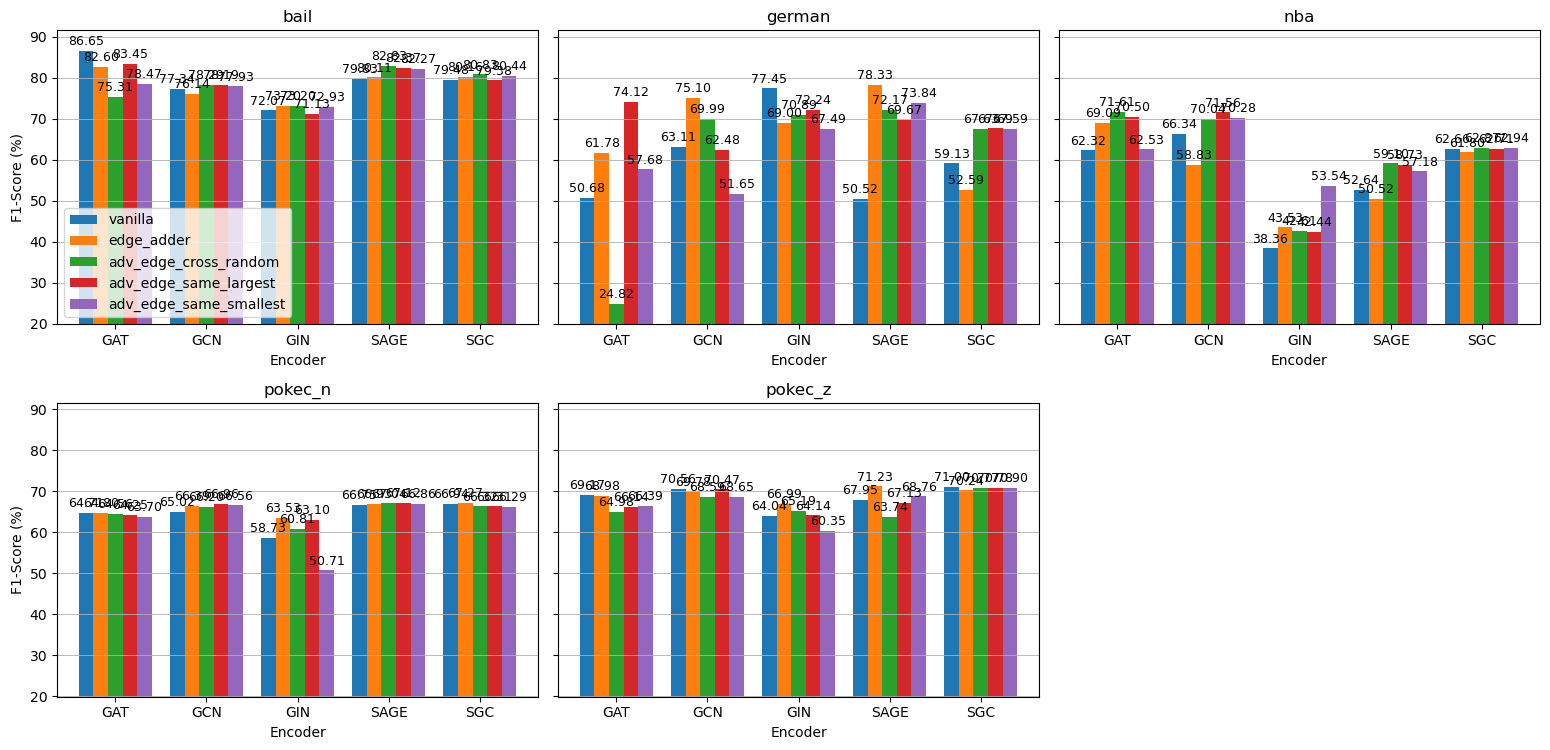

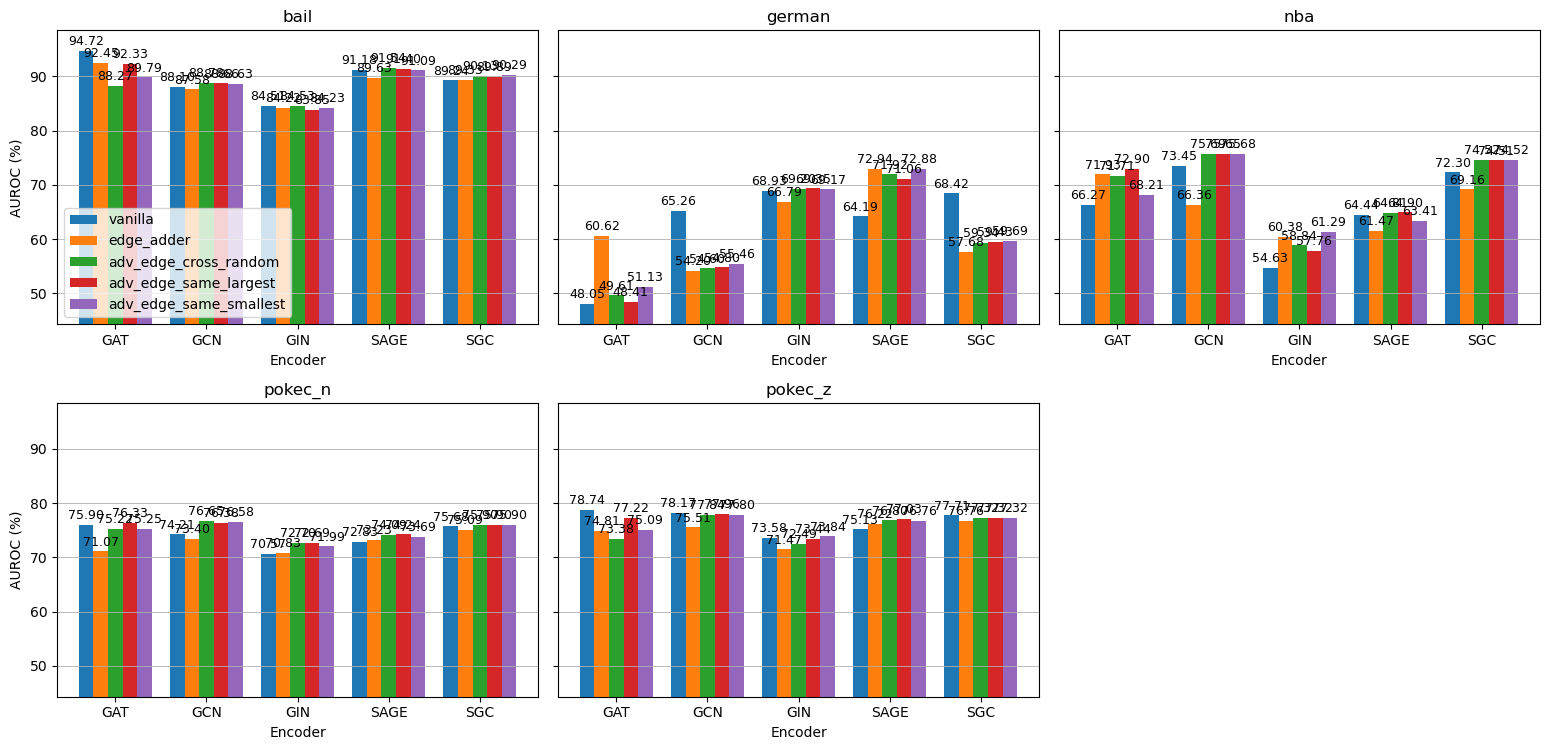

In [66]:
for metric in METRIC_KEYS:
    pt_percent = (pts_clean[metric] * 100).round(2)

    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=lst_methods,
        metric_label=f"{MAP_METRIC_TO_LABEL.get(metric, metric.upper())} (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

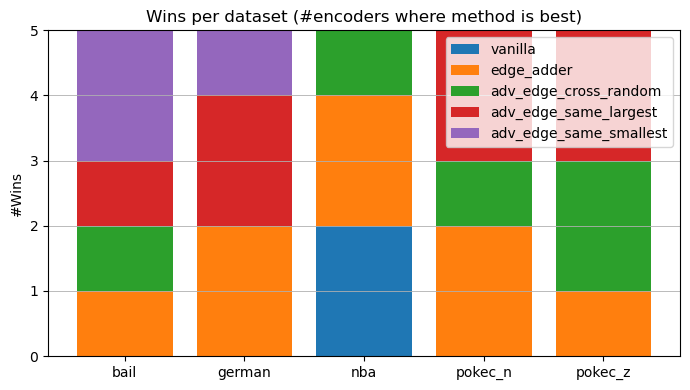

In [67]:
metric = "dp_mean"
pt_percent = (pts_clean[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

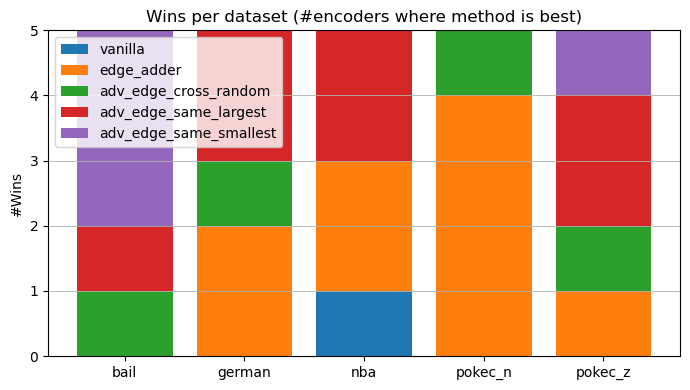

In [68]:
metric = "eo_mean"
pt_percent = (pts_clean[metric] * 100).round(2)

counts = win_counts(pt_percent, better="min")  # DP often: lower is better
plot_win_counts(counts)
plt.show()

## Test attack split

In [69]:
df_baseline = pd.read_csv("./df_compare_vanilla_ea.csv")
df_baseline.shape

(50, 17)

In [70]:
ROOT_RESULTS = "./advtrain_edge"
exp_folders=(
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-cross_random",
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-same_largest",
    "edge_weight_k-5_dp-2.0_eo-2.0_policy-same_smallest"
)

lst_methods = ["vanilla", "edge_adder"]
lst_dfs = [df_baseline]
for exp_dir in exp_folders:
    policy = exp_dir.split("policy-")[-1]
    fn = f"{ROOT_RESULTS}/{exp_dir}/aggregated_results_test.csv"
    df_attacked_adv = pd.read_csv(fn)
    method = f"adv_edge_{policy}"
    df_attacked_adv["method"] = method
    lst_methods.append(method)
    lst_dfs.append(df_attacked_adv)

df_attacked = pd.concat(lst_dfs, ignore_index=True)
df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=lst_methods, ordered=True)
df_attacked.shape

(125, 25)

In [71]:
df_attacked["method"].value_counts()

method
vanilla                   25
edge_adder                25
adv_edge_cross_random     25
adv_edge_same_largest     25
adv_edge_same_smallest    25
Name: count, dtype: int64

In [ ]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}


In [73]:
def get_pts(df: pd.DataFrame, metric: str):
    pt = df.pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )
    return pt

pts_attacked = {}
for metric in METRIC_KEYS:
    pts_attacked[metric] = get_pts(df_attacked, metric)

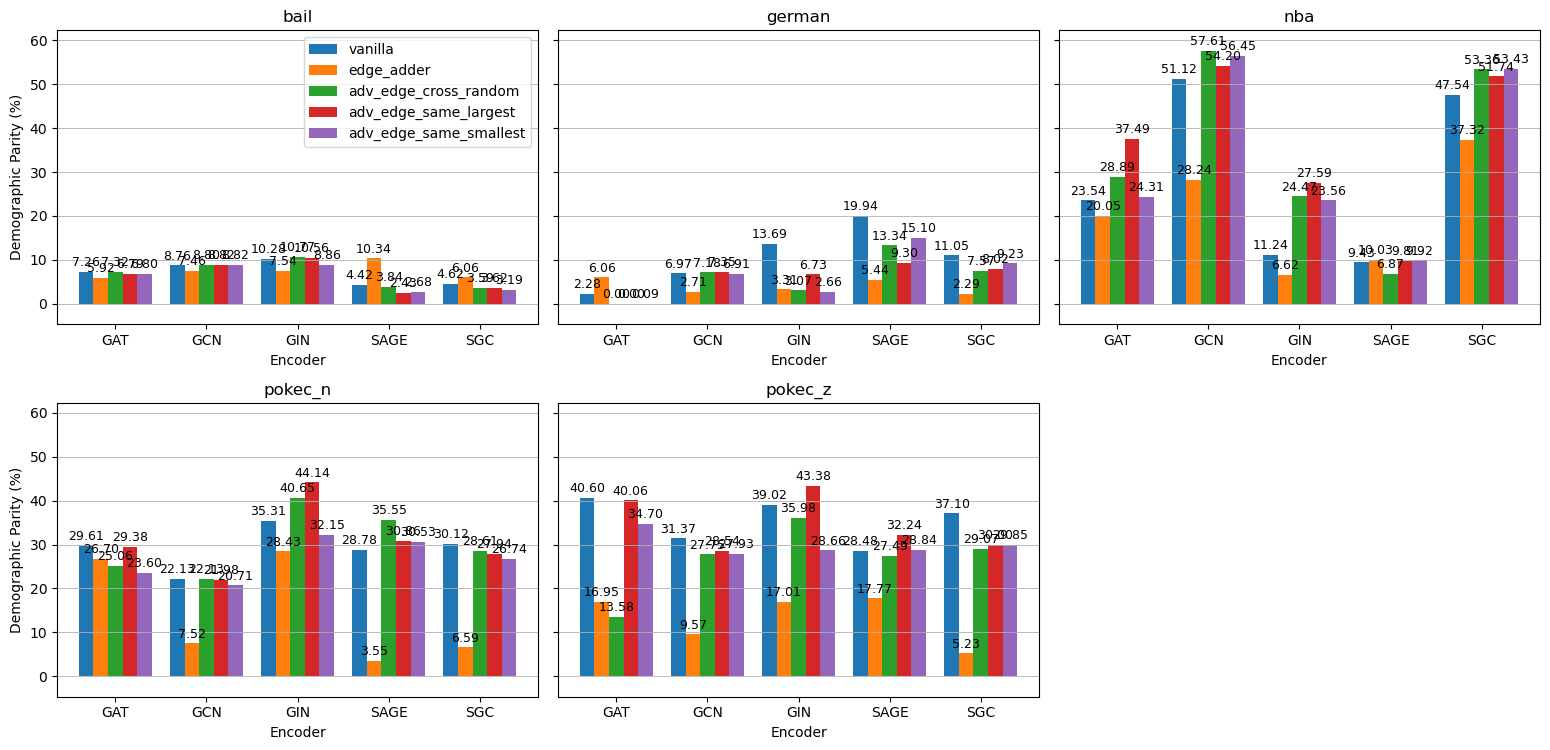

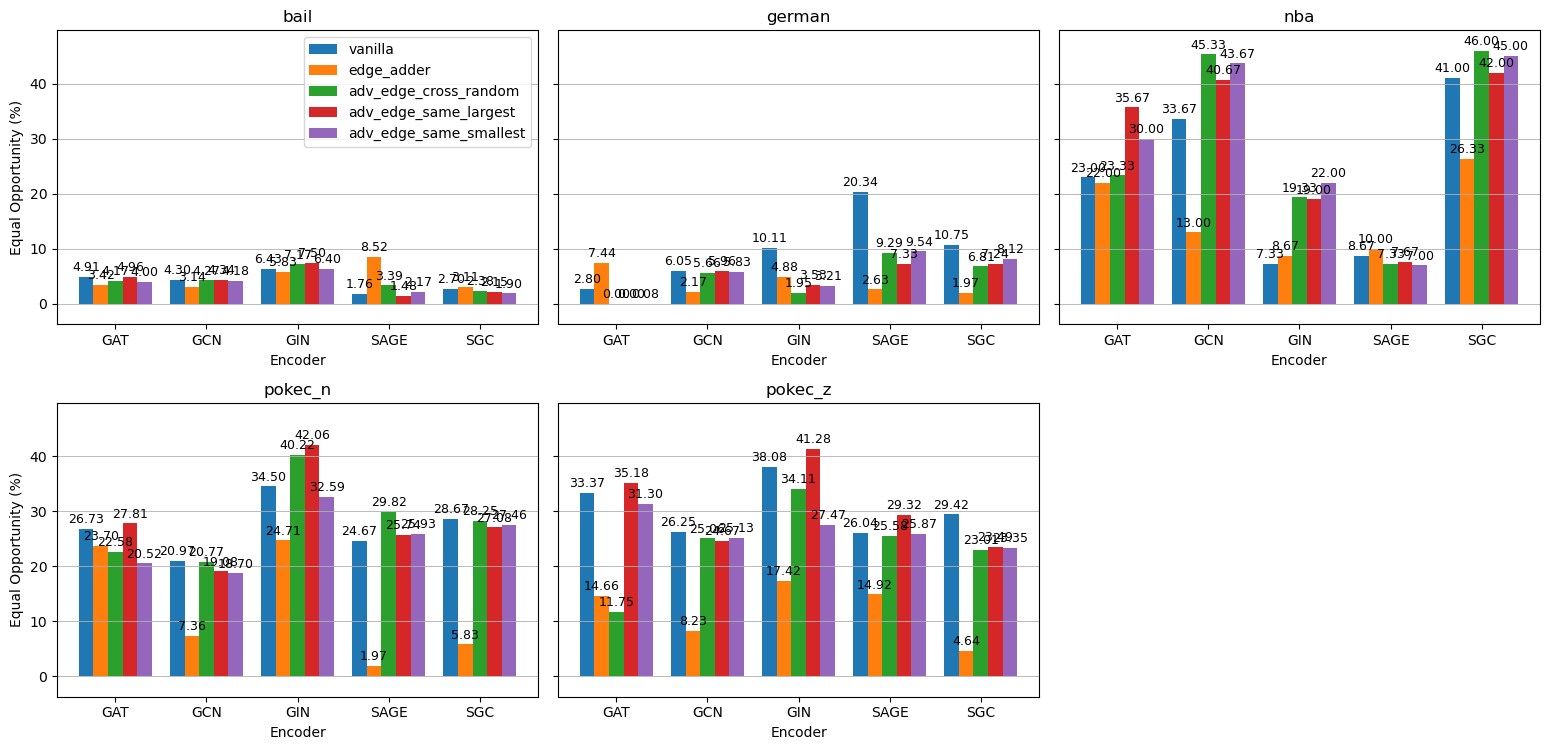

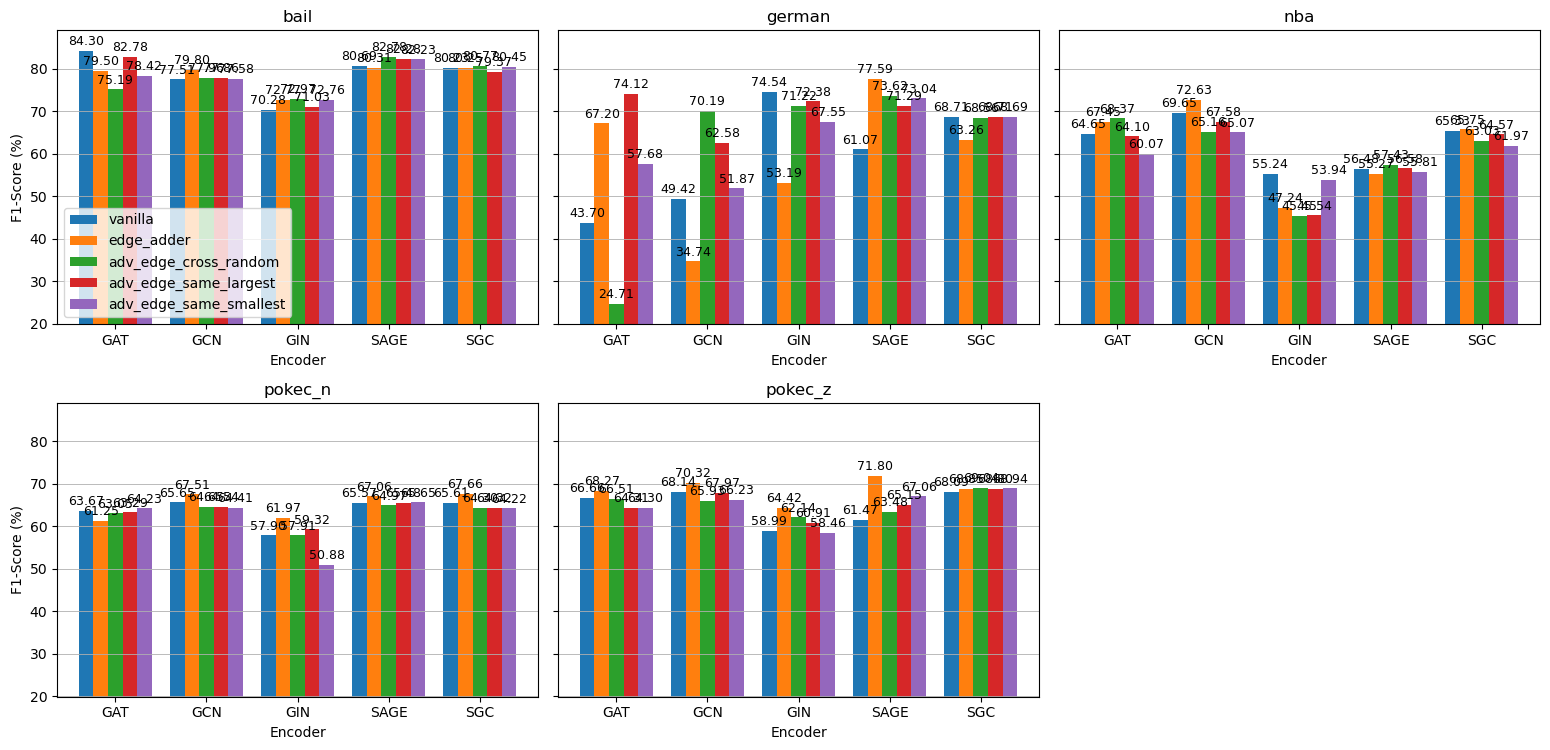

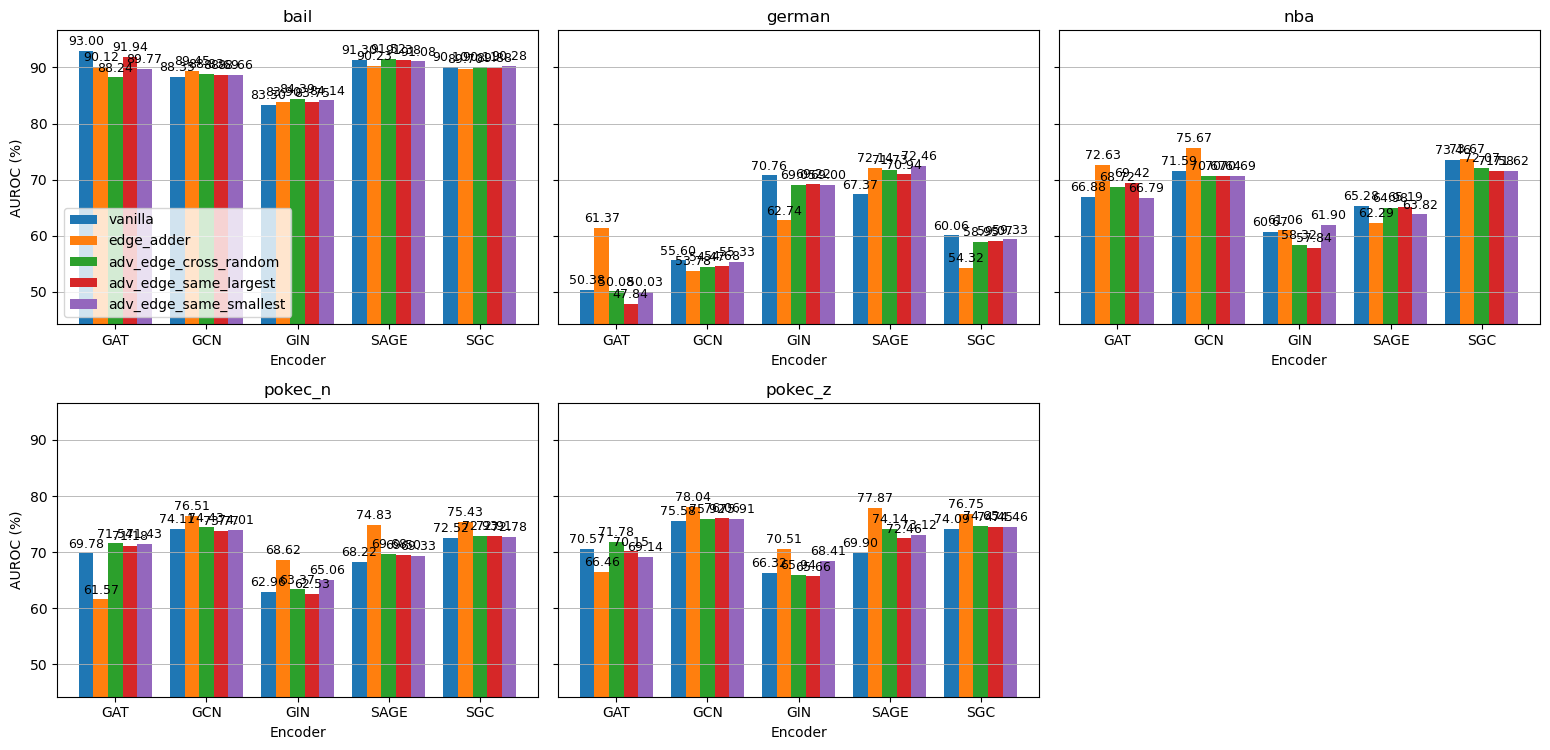

In [74]:
for metric in METRIC_KEYS:
    pt_percent = (pts_attacked[metric] * 100).round(2)

    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=lst_methods,
        metric_label=f"{MAP_METRIC_TO_LABEL.get(metric, metric.upper())} (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

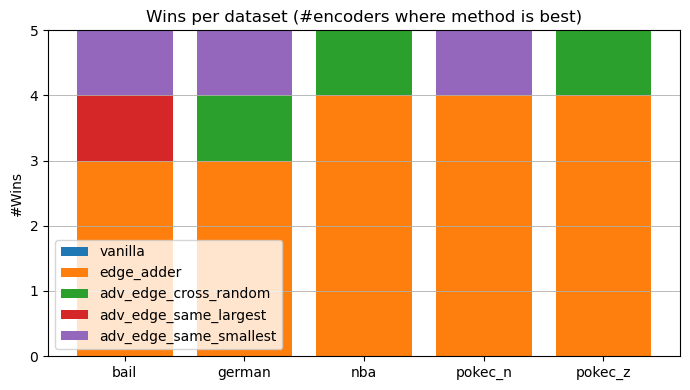

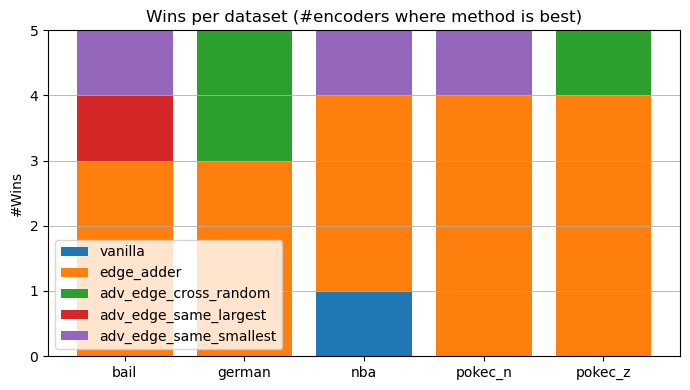

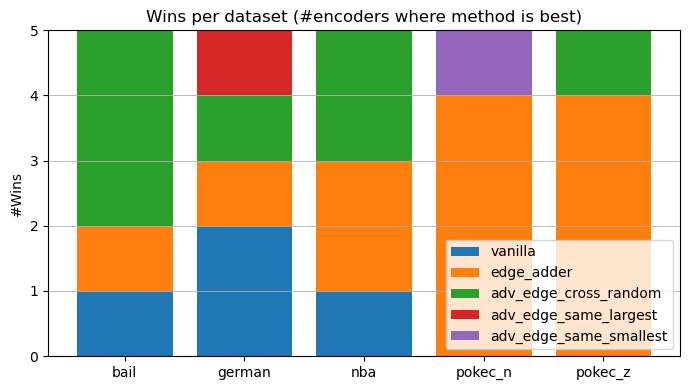

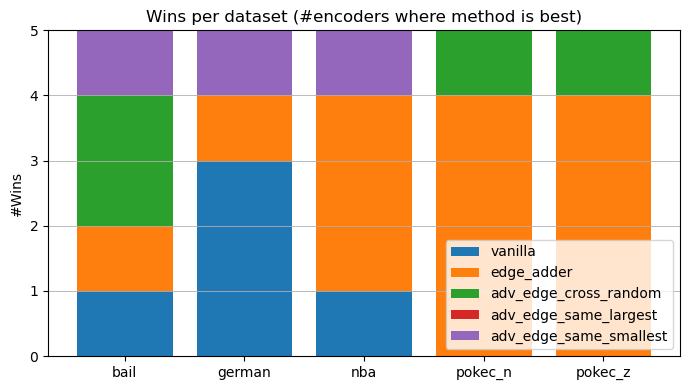

In [76]:
for metric in METRIC_KEYS:
    pt_percent = (pts_attacked[metric] * 100).round(2)
    better = "min" if metric in ["dp_mean", "eo_mean"] else "max"
    counts = win_counts(pt_percent, better=better)
    plot_win_counts(counts)
    plt.show()

# AdvTrain Edge - K=5 with different policies (exlcuding task loss from inner maximization)

## Test clean split

In [4]:
fn = "./20260118/vanilla/df_vanilla_clean_and_tuned_nifa.csv"
df_baseline_vanilla = pd.read_csv(fn)
df_baseline_vanilla["method"] = "vanilla"

fn = "./20260118/ea/df_ea_clean_and_tuned_nifa.csv"
df_baseline_ea = pd.read_csv(fn)
df_baseline_ea["method"] = "edge_adder"

df_baseline = pd.concat([
    df_baseline_vanilla[df_baseline_vanilla["attack_mode"] == "no_attack"],
    df_baseline_ea[df_baseline_ea["attack_mode"] == "no_attack"]
], ignore_index=True)
df_baseline["method"] = pd.Categorical(df_baseline["method"], categories=["vanilla", "edge_adder", "vanilla_advtrain"], ordered=True)
df_baseline.columns = [c.lower() for c in df_baseline.columns]
df_baseline.shape


(50, 16)

In [8]:
ROOT_RESULTS = "./advtrain_edge_fairness_only"
exp_folders=[
    "edge_weight_mode-mix_k-5_dp-2.0_eo-2.0_policy-global_random"
]

lst_methods = ["vanilla", "edge_adder"]
lst_dfs = [df_baseline]
for exp_dir in exp_folders:
    policy = exp_dir.split("policy-")[-1]
    fn = f"{ROOT_RESULTS}/{exp_dir}/aggregated_results_test_clean.csv"
    df_clean_adv = pd.read_csv(fn)
    method = f"adv_edge_{policy}"
    df_clean_adv["method"] = method
    lst_methods.append(method)
    lst_dfs.append(df_clean_adv)

df_clean = pd.concat(lst_dfs, ignore_index=True)
df_clean["method"] = pd.Categorical(df_clean["method"], categories=lst_methods, ordered=True)
df_clean.shape

(65, 24)

In [9]:
df_clean["method"].value_counts()

method
vanilla                   25
edge_adder                25
adv_edge_global_random    15
Name: count, dtype: int64

In [10]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}
pts_clean = {}

0     True
1     True
2     True
3     True
4     True
      ... 
60    True
61    True
62    True
63    True
64    True
Name: dataset, Length: 65, dtype: bool

In [16]:
datasets_selected = ["bail", "pokec_z", "pokec_n"]
idx_selected = df_clean["dataset"].apply(lambda x: x in datasets_selected)

for metric in METRIC_KEYS:
    pt = df_clean.loc[idx_selected, :].pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )
    pts_clean[metric] = pt

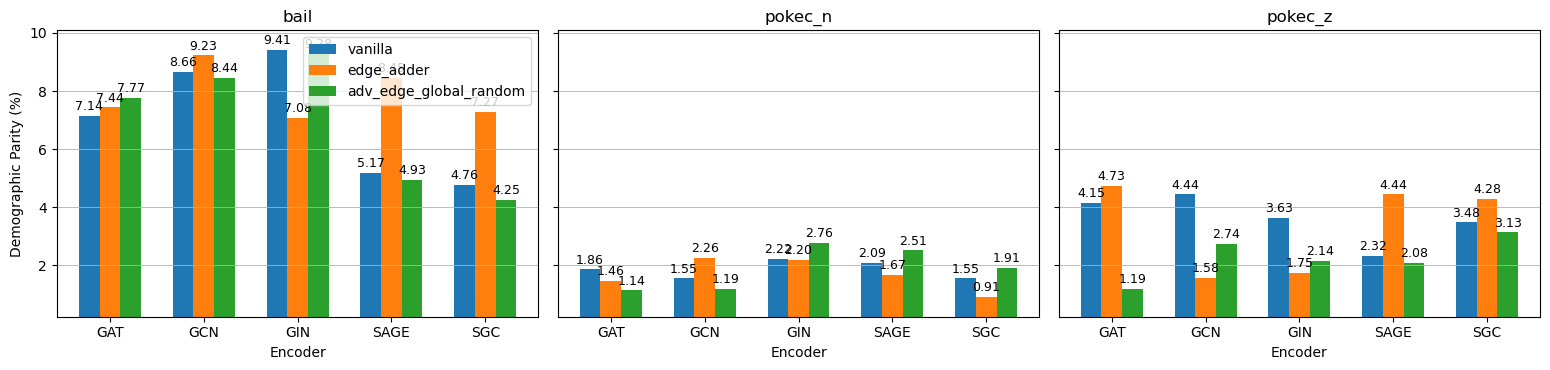

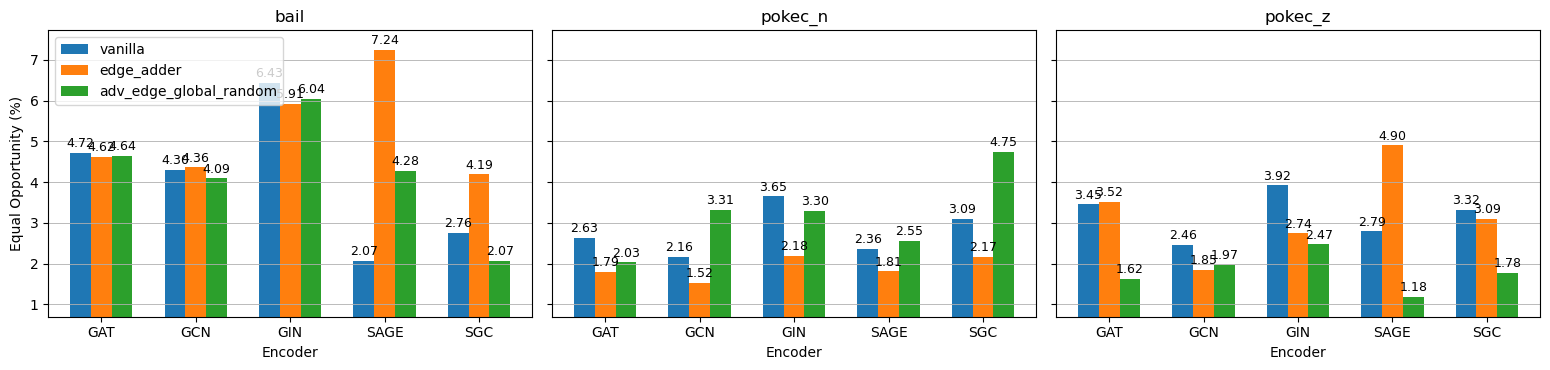

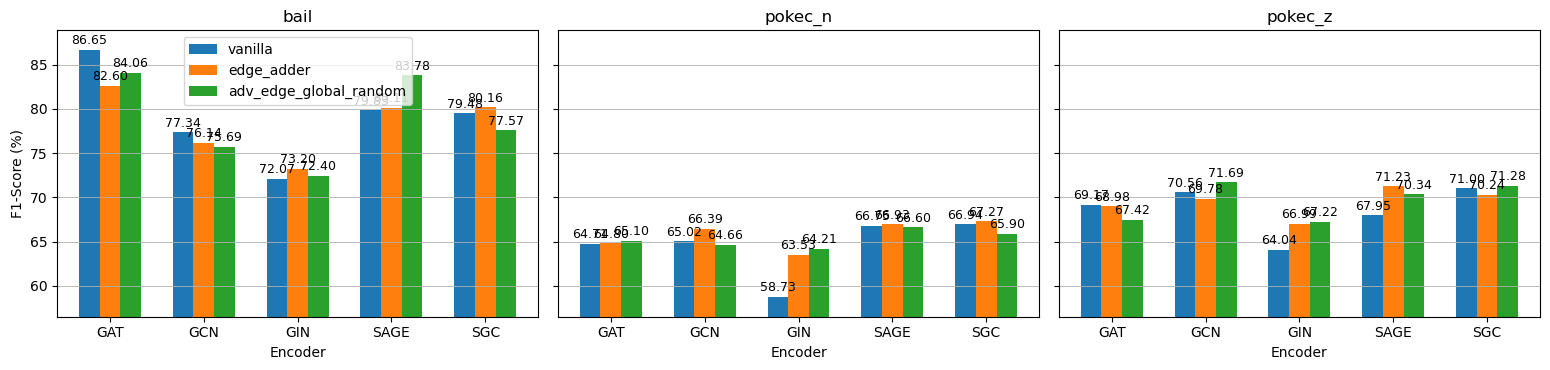

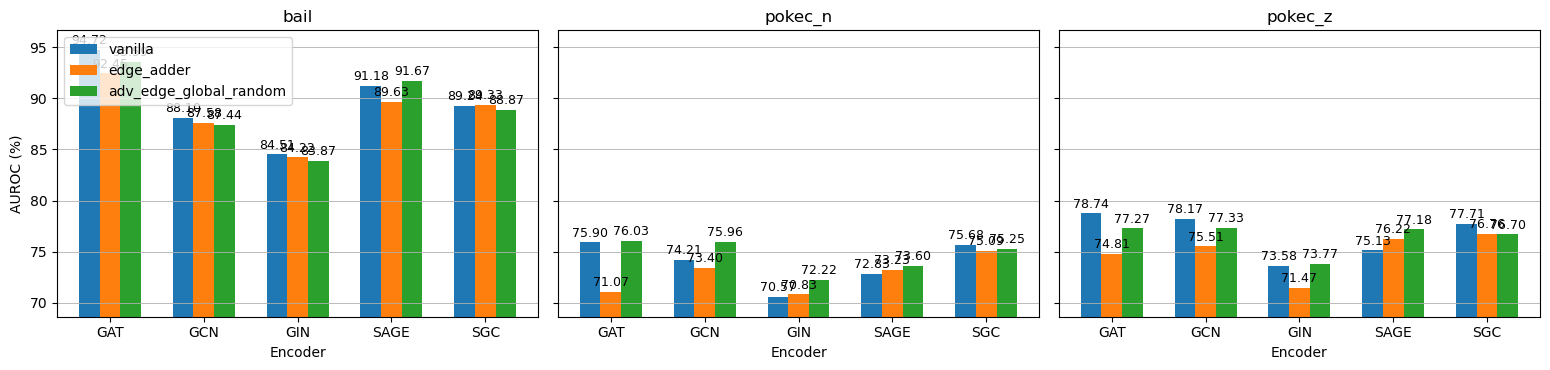

In [17]:
for metric in METRIC_KEYS:
    pt_percent = (pts_clean[metric] * 100).round(2)

    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=lst_methods,
        metric_label=f"{MAP_METRIC_TO_LABEL.get(metric, metric.upper())} (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

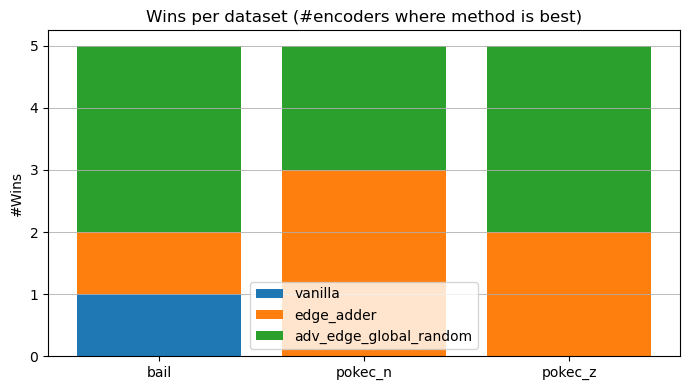

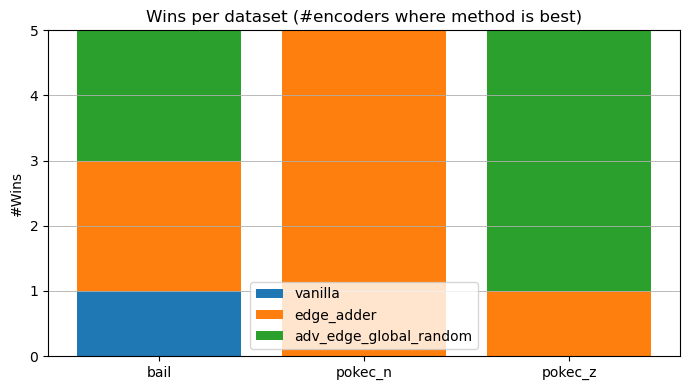

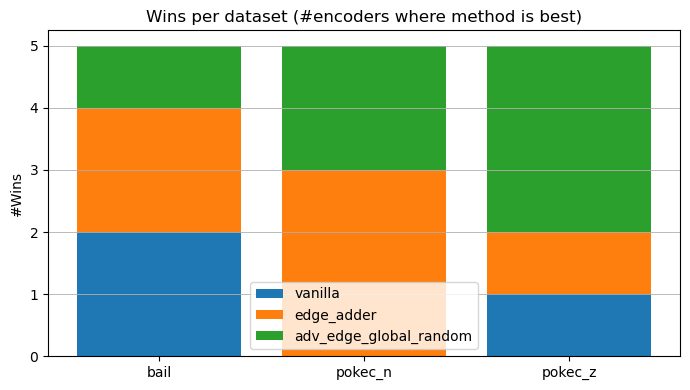

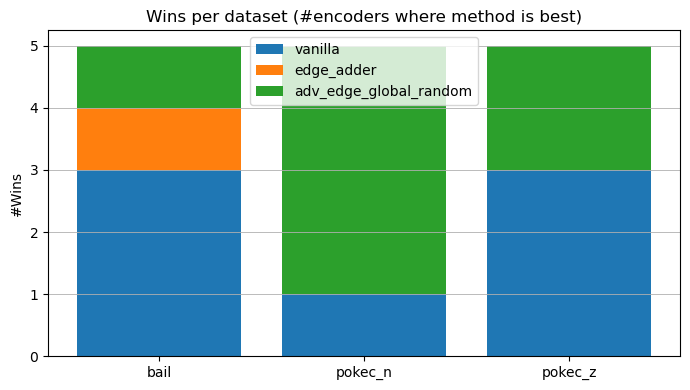

In [18]:
for metric in METRIC_KEYS:
    pt_percent = (pts_clean[metric] * 100).round(2)
    better = "min" if metric in ["dp_mean", "eo_mean"] else "max"
    counts = win_counts(pt_percent, better=better)
    plot_win_counts(counts)
    plt.show()

## Test attack split

In [26]:
df_baseline = pd.read_csv("./df_compare_vanilla_ea.csv")
df_baseline.shape

(50, 17)

In [27]:
ROOT_RESULTS = "./advtrain_edge_fairness_only"
exp_folders=[
    "edge_weight_mode-mix_k-5_dp-2.0_eo-2.0_policy-global_random"
]

lst_methods = ["vanilla", "edge_adder"]
lst_dfs = [df_baseline]
for exp_dir in exp_folders:
    policy = exp_dir.split("policy-")[-1]
    fn = f"{ROOT_RESULTS}/{exp_dir}/aggregated_results_test.csv"
    df_attacked_adv = pd.read_csv(fn)
    method = f"adv_edge_{policy}"
    df_attacked_adv["method"] = method
    lst_methods.append(method)
    lst_dfs.append(df_attacked_adv)

df_attacked = pd.concat(lst_dfs, ignore_index=True)
df_attacked["method"] = pd.Categorical(df_attacked["method"], categories=lst_methods, ordered=True)
df_attacked.shape

(65, 25)

In [28]:
df_attacked["method"].value_counts()

method
vanilla                   25
edge_adder                25
adv_edge_global_random    15
Name: count, dtype: int64

In [29]:
METRIC_KEYS = ["dp_mean", "eo_mean", "f1_mean", "auc_mean"]
MAP_METRIC_TO_LABEL = {
    "dp_mean": "Demographic Parity",
    "eo_mean": "Equal Opportunity",
    "f1_mean": "F1-Score",
    "auc_mean": "AUROC",
}

In [30]:
def get_pts(df: pd.DataFrame, metric: str, datasets_selected: Optional[List[str]] = None):
    if datasets_selected is not None:
        df = df[df["dataset"].isin(datasets_selected)]
    pt = df.pivot_table(
        index=["dataset", "method"],
        columns=["encoder"],
        values=metric,
        observed=False
    )
    return pt

pts_attacked = {}
datasets_selected = ["bail", "pokec_z", "pokec_n"]
for metric in METRIC_KEYS:
    pts_attacked[metric] = get_pts(df_attacked, metric, datasets_selected)

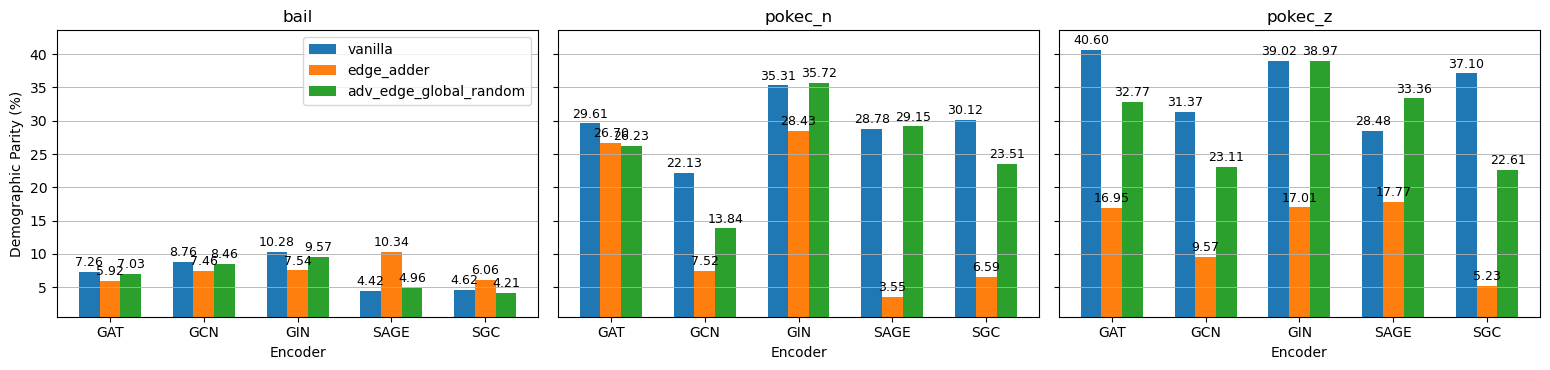

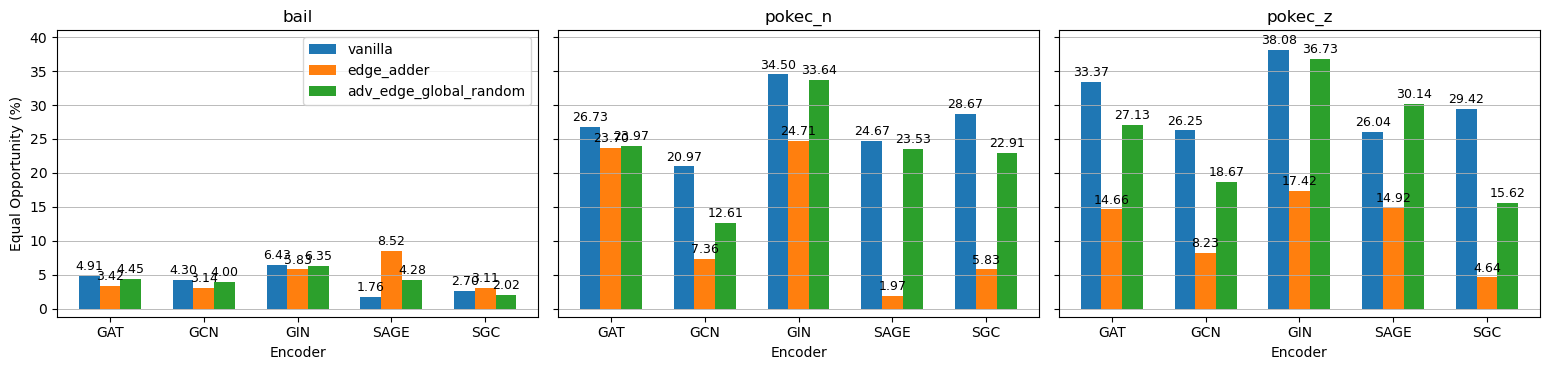

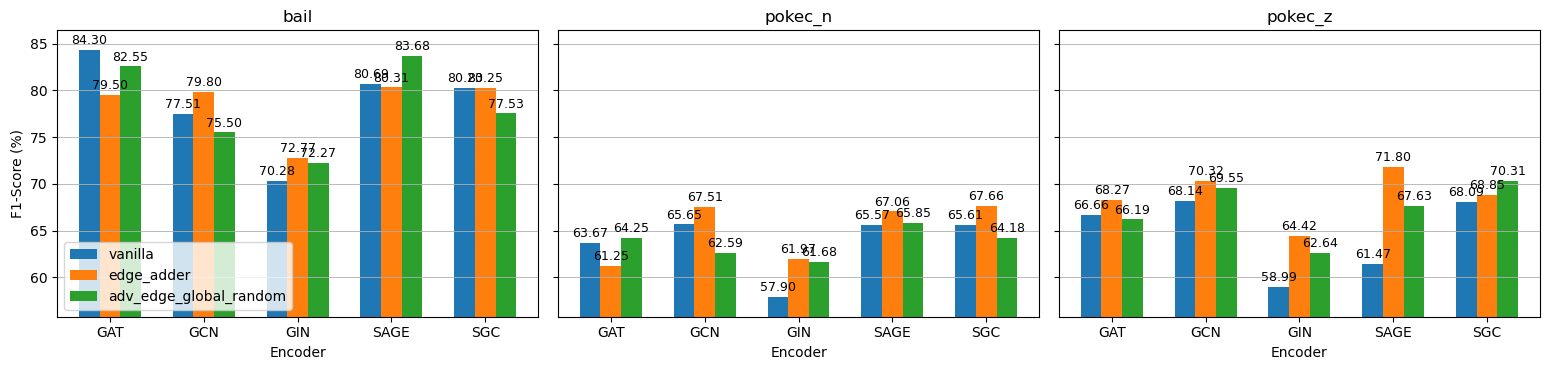

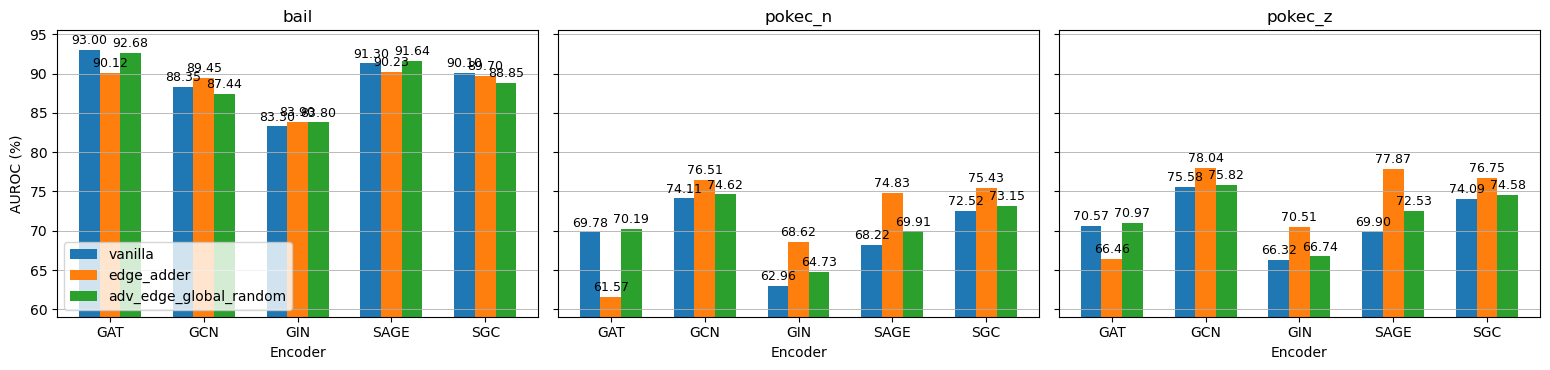

In [31]:
for metric in METRIC_KEYS:
    pt_percent = (pts_attacked[metric] * 100).round(2)

    plot_grouped_bars_per_dataset(
        pt_percent,
        methods=lst_methods,
        metric_label=f"{MAP_METRIC_TO_LABEL.get(metric, metric.upper())} (%)",
        ncols=3,
        rotate_xticks=0,
    )
    plt.show()

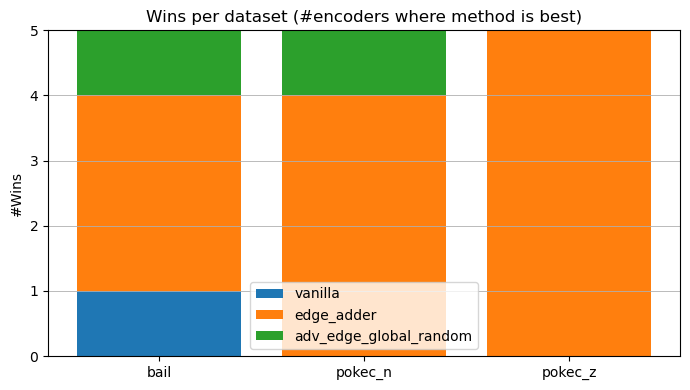

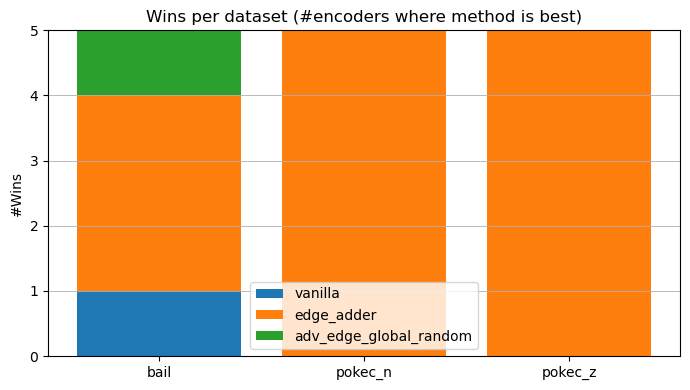

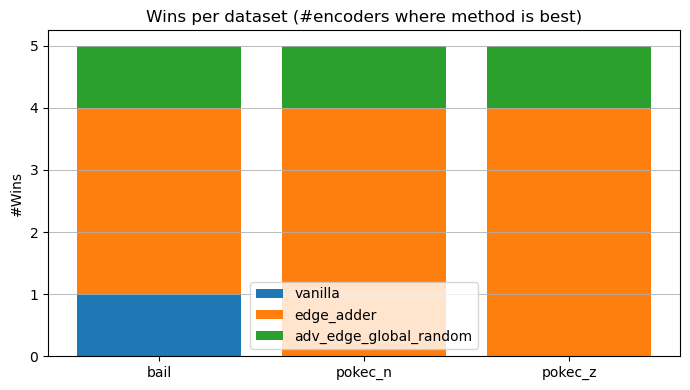

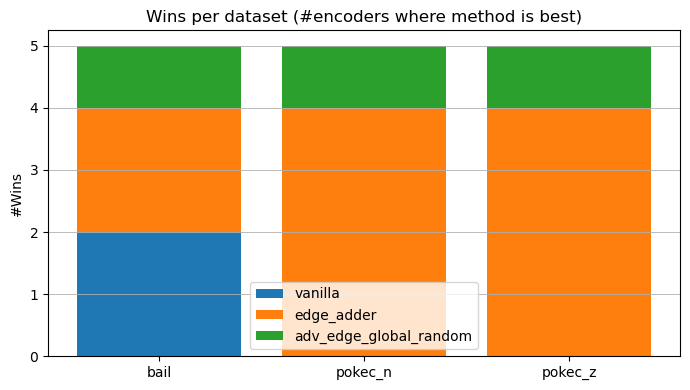

In [32]:
for metric in METRIC_KEYS:
    pt_percent = (pts_attacked[metric] * 100).round(2)
    better = "min" if metric in ["dp_mean", "eo_mean"] else "max"
    counts = win_counts(pt_percent, better=better)
    plot_win_counts(counts)
    plt.show()